<a href="https://colab.research.google.com/github/BiswanathB/Physics-Informed-Neural-Networks-PINNs-Pytorch-GPU-based-implementation/blob/main/PINNs_Implemenation_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Physics-informed neural networks (PINNs)**
## **Tutorial part 1: PINNs for Burgers' equation Forward Problem**
#### **PINNs Discussion Series**


## Table of content:
1. [Introduction to vanilla PINNs](#1-bullet)
    * [Example: Viscous Burgers equation](#1.1-bullet)
    

#### Loading package

## 1. Introduction to vanilla PINNs <a name="1-bullet"></a>

First, let us recall the general formulation of the vanilla PINNs. Considering the following parameterized PDE defined on the domain $\Omega \subset \mathbb{R}^d$ with the boundary $\partial\Omega$:
\begin{align}
&\partial_t \boldsymbol{u} + \mathcal{N}_\boldsymbol{\mathrm{x}}(\boldsymbol{u}, \lambda)=0, \text{ for } \boldsymbol{\mathrm{x}}\in\Omega, t\in[0,T]\\
&\boldsymbol{u}(\boldsymbol{\mathrm{x}},0)=g(\boldsymbol{\mathrm{x}}), \text{ for } \boldsymbol{\mathrm{x}}\in\Omega\\
&\mathcal{B}(\boldsymbol{u},\boldsymbol{\mathrm{x}},t)=0, \text{ for } \boldsymbol{\mathrm{x}}\in\partial\Omega\\
\end{align}
where $\boldsymbol{\mathrm{x}} \in \mathbb{R}^d$ and $t$ are the spatial and temporal coordinates, $\mathcal{N}_{\boldsymbol{\mathrm{x}}}$ is a differential operator, $\boldsymbol{\lambda}$ is the PDE parameter, $\boldsymbol{u}$ is the solution of the PDE with initial condition $g(\boldsymbol{\mathrm{x}})$ and boundary condition $\mathcal{B}$, which could be Dirichlet, Neumann, Robin, or periodic boundary conditions. The subscripts denote the partial differentiation in time or space. In PINNs, the solution $\boldsymbol{u}$ of the PDE is approximated by a fully-connected feedforward neural network $\mathcal{NN}$:
\begin{align*}
    \boldsymbol{u} \approx \hat{\boldsymbol{u}} = \mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})
\end{align*}
where $\hat{\boldsymbol{u}}$ denotes the prediction value for the solution and $\boldsymbol{\theta}$ denotes the trainable parameters of the neural network. The parameters of the neural network are trained by minimizing the cost function $L$:
\begin{align}
    L = L_{pde} + L_{ic} + L_{bc} + L_{data}
\end{align}
where the terms $L_{pde},L_{ic},L_{bc}$ and $L_{data}$ penalize the loss in the residual of the PDE, the initial condition, the boundary condition, and the supervised data (measurements), respectively, which can be represented as follow:
\begin{align*}
    L_{pde} &= \dfrac{1}{N_{pde}}\sum_{i=1}^{N_{pde}}|\hat{\boldsymbol{u}}_{t^i} + \mathcal{N}_{\boldsymbol{\mathrm{x}}^{i}}(\hat{\boldsymbol{u}^{i}}, \boldsymbol{\lambda})|^2\\
    L_{ic} &= \dfrac{w_{ic}}{N_{ic}}\sum_{i=1}^{N_{ic}}|\boldsymbol{\hat{u}}(\boldsymbol{\mathrm{x}}^i,0) - g(\boldsymbol{\mathrm{x}}^i)|^2\\
    L_{bc} &= \dfrac{w_{bc}}{N_{bc}}\sum_{i=1}^{N_{bc}}|\mathcal{B}(\hat{\boldsymbol{u}^i}, \boldsymbol{\mathrm{x}}^{i}, t^{i})|^2\\
    L_{data} &= \dfrac{w_{data}}{N_{data}}\sum_{i=1}^{N_{data}}|\hat{\boldsymbol{u}}(\boldsymbol{\mathrm{x}}^i,t^i) - \boldsymbol{u}(\boldsymbol{\mathrm{x}}^i,t^i)|^2\\
\end{align*}
where $w_{ic}, w_{bc}, w_{data}$ are the weights to balance different terms in the cost function.

The definition of the cost function $L$ and the trainable parameters depend on the problems:

|Type of problem | Input of $\mathcal{NN}$ | Trainable parameter | Loss function |
| :- | -: | -: |-: |
| Forward | $(\boldsymbol{\mathrm{x}},t)$ | $\theta$ | $L = L_{pde} + L_{ic} + L_{bc}$
| Inverse | $(\boldsymbol{\mathrm{x}},t)$ | $\theta,\lambda$ | $L = L_{pde} + L_{data}$
| Ill-posed | $(\boldsymbol{\mathrm{x}},t)$ | $\theta$ | $L = L_{pde} + L_{data}$
| Generalization | $(\boldsymbol{\mathrm{x}},t,\lambda)$ | $\theta$ | $L = L_{pde} + L_{ic} + L_{bc}$


## Forward problem
In forward problems, the initial and/or boundary conditions (IC and/or BCs) of the PDEs are well-defined. The measurements of the solutions (supervised data) are optional. We aim to infer the solution in the entire domain using PINNs.

To solve a PDE problem, there exists two equivalent formulations: the strong form and the weak form.
* The strong form consists of the differential equations along with IC and BCs. It imposes continuity and differentiability requirements on the potential solutions to the equation.
* The weak form is an alternative representation of the differential equations, which relaxes the continuity and differentiability requirements. It reduces the order of the derivatives and forces the solution to satisfied an integral functions.

### Example: Viscous Burgers equation <a name="1.1-bullet"></a>
We consider the following viscous Burgers equation:
\begin{align}
  &u_t + uu_x -\nu u_{xx} = 0 \quad \text{for } x\in [-1,1], t\in[0, 1] \\
  &u(x,0) = -\sin(\pi x) \quad \text{for } x\in [-1,1]\\
  &u(-1,t) = u(1,t) = 0 \quad \text{for } t\in [0,1]
\end{align}
where $\nu$ is the PDE parameter. In this section, we take $\nu=0.025$.

We denote $\hat{u}=\mathcal{NN}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})$ the prediction of PINNs for the solution. The loss function, which includes the loss the IC/BC and the PDE residuals, now becomes:
\begin{align}
  L &= L_{pde} + L_{ic} + L_{bc}\\
    &= \dfrac{1}{N_{pde}}\sum_{i=1}^{N_{pde}}|\hat{u}^i_{t} + \hat{u}^i\hat{u}^i_{x}-\nu \hat{u}_{xx}|^2 + \dfrac{w_{ic}}{N_{ic}}\sum_{i=1}^{N_{ic}}|\hat{u}(x^i,0) + \sin(\pi x^i)|^2 + \dfrac{w_{bc}}{N_{bc}}\sum_{i=1}^{N_{bc}}(|\hat{u}(-1,t^i)|^2+|\hat{u}(1,t^i)|^2)
\end{align}
Here we will take $w_{ic}=w_{bc}=1$.

We take the following steps to train PINNs:
* Define the domain
* Define the initial/boundary conditions (IC/BC) and the training points
* Define PDE residuals and loss term for the PDE
* Define PINNs architecture
* Train PINNs



## **Dataset Acquisition**

The exact dataset utilized in this study is derived from the seminal work of Raissi et al. (2019), specifically their publication: Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). "Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations." *Journal of Computational Physics*, 378, 686-707. [Link to paper](https://www.sciencedirect.com/science/article/pii/S0021999118307125)

In [ ]:
import requests

!mkdir -p data
# Correct URL to download the raw .mat file
url = "https://raw.githubusercontent.com/maziarraissi/PINNs/master/appendix/Data/burgers_shock.mat"
response = requests.get(url)

if response.status_code == 200:
    with open("data/burgers_shock.mat", "wb") as f:
        f.write(response.content)
    print("File downloaded successfully to data/burgers_shock.mat")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

File downloaded successfully to data/burgers_shock.mat


# **LHS sampling purpose**

In [ ]:
!pip install pyDOE

# **Libraries and Dependencies**

In [ ]:
import torch                                    # PyTorch for neural networks and autograd
from collections import OrderedDict             # maintain ordered layers in neural network

from pyDOE import lhs                           # Latin Hypercube Sampling for collocation points
import numpy as np                              # numerical array operations
import matplotlib.pyplot as plt                 # plotting and visualization
import scipy.io                                 # load MATLAB .mat data files
from scipy.interpolate import griddata          # interpolate data onto structured grid

# from plotting import newfig, savefig            # custom plotting utilities
from mpl_toolkits.axes_grid1 import make_axes_locatable  # attach colorbars to plots
import matplotlib.gridspec as gridspec          # flexible subplot layouts

import time                                     # measure training runtime

np.random.seed(1234)                            # set random seed for reproducibility

# **GPU Initialization**

In [ ]:
# CUDA support
if torch.cuda.is_available():            # check if a CUDA-enabled GPU is available
    device = torch.device('cuda')       # use GPU for faster tensor computations
else:
    device = torch.device('cpu')        # otherwise use CPU for computations

# **Initialize DNN Architecture**

In [ ]:
# Define the deep neural network architecture
class DNN(torch.nn.Module):                         # create a neural network class by inheriting from PyTorch Module

    def __init__(self, layers):
        super(DNN, self).__init__()                  # initialize the parent class so PyTorch can track parameters

        # number of layers in the neural network
        self.depth = len(layers) - 1                 # depth = number of linear transformations between layers

        # choose activation function for hidden layers
        self.activation = torch.nn.Tanh              # hyperbolic tangent activation (commonly used in PINNs)

        layer_list = list()                          # create an empty list to store network layers

        # build hidden layers
        for i in range(self.depth - 1):               # loop through all layers except the final output layer

            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )                                        # create a fully connected layer mapping layers[i] → layers[i+1]

            layer_list.append(
                ('activation_%d' % i, self.activation())
            )                                        # apply Tanh activation after each hidden linear layer

        # create final output layer (without activation)
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )                                            # last linear layer maps last hidden layer → output

        layerDict = OrderedDict(layer_list)          # convert list into OrderedDict to preserve layer order

        # create the neural network using Sequential container
        self.layers = torch.nn.Sequential(layerDict) # sequentially apply layers during forward pass

        # move model to GPU if available, otherwise CPU
        self.layers.to(device)                       # ensures model parameters are stored on selected device

    def forward(self, x):
        x = x.to(device)                             # move input tensor to same device as model (GPU or CPU)
        out = self.layers(x)                         # pass input through all layers of the network
        return out                                   # return predicted output

# **PINNs class**

In [ ]:
# Physics-Informed Neural Network class
class PhysicsInformedNN():

    def __init__(self, X_u, u, X_f, layers, lb, ub, nu):

        # domain bounds
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)
        # lower and upper bounds of the computational domain, stored on GPU/CPU


        # training data for boundary/initial conditions
        self.x_u = torch.tensor(X_u[:,0:1],requires_grad=True).float().to(device)
        self.t_u = torch.tensor(X_u[:,1:2],requires_grad=True).float().to(device)
        self.u   = torch.tensor(u).float().to(device)
        # (x_u , t_u) are coordinates where solution u is known (boundary or initial condition)

        # collocation points for enforcing the PDE
        self.x_f = torch.tensor(X_f[:,0:1],requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:,1:2],requires_grad=True).float().to(device)
        # these points are sampled inside the domain where the PDE residual is minimized

        self.layers = layers
        self.nu = nu                       # viscosity coefficient in Burgers equation
        # store loss history for plotting
        self.loss_total = []
        self.loss_u_history = []
        self.loss_f_history = []
        self.iter_history = []

        # neural network model
        self.dnn = DNN(layers).to(device)  # deep neural network approximating u(x,t)

        # optimizer (commonly used in PINNs)
        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1.0*np.finfo(float).eps,
            line_search_fn="strong_wolfe"
        )
        # LBFGS works well for PINNs because it uses second-order information

        self.iter = 0


    def net_u(self, x, t):

        u = self.dnn(torch.cat([x,t],dim=1))
        # concatenate x and t so the neural network input becomes [x,t]

        return u
        # neural network output approximates the PDE solution u(x,t)


    def net_f(self, x, t):
        """
        compute PDE residual using automatic differentiation
        """

        u = self.net_u(x,t)

        # compute time derivative
        u_t = torch.autograd.grad(
            u,t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        # compute spatial derivative
        u_x = torch.autograd.grad(
            u,x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        # compute second spatial derivative
        u_xx = torch.autograd.grad(
            u_x,x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]

        # Burgers equation residual
        f = u_t + u*u_x - self.nu*u_xx
        # PINN tries to minimize this residual toward zero

        return f


    def loss_func(self):

        self.optimizer.zero_grad()

        # prediction at boundary/initial condition points
        u_pred = self.net_u(self.x_u,self.t_u)

        # PDE residual at collocation points
        f_pred = self.net_f(self.x_f,self.t_f)

        # data loss (boundary/initial conditions)
        loss_u = torch.mean((self.u-u_pred)**2)

        # physics loss (PDE residual)
        loss_f = torch.mean(f_pred**2)

        # total PINN loss
        loss = loss_u + loss_f

        loss.backward()   # compute gradients for optimization

        self.iter += 1
        if self.iter % 100 == 0:

          # store losses for plotting
          self.iter_history.append(self.iter)
          self.loss_total.append(loss.item())
          self.loss_u_history.append(loss_u.item())
          self.loss_f_history.append(loss_f.item())

          print(
              'Iter %d, Loss: %.5e, Loss_u: %.5e, Loss_f: %.5e'
              % (self.iter, loss.item(), loss_u.item(), loss_f.item())
          )
            # print training progress every 100 iterations

        return loss


    def train(self):

        self.dnn.train()

        # run optimizer step
        self.optimizer.step(self.loss_func)
        # LBFGS internally calls loss_func multiple times


    def predict(self,X):

        x = torch.tensor(X[:,0:1],requires_grad=True).float().to(device)
        t = torch.tensor(X[:,1:2],requires_grad=True).float().to(device)

        self.dnn.eval()

        u = self.net_u(x,t)    # predicted solution
        f = self.net_f(x,t)    # PDE residual

        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy()
        # convert tensors to numpy arrays for plotting

        return u,f

# **Configurations Details**

In [ ]:
# ================================
# Physical parameter of PDE
# ================================

nu = 0.01 / np.pi
# viscosity coefficient used in Burgers equation
# ν controls diffusion strength in the PDE

noise = 0.0
# noise level in training data
# here data is assumed to be clean (no noise)


# ================================
# Training data configuration
# ================================

N_u = 100
# number of training points used from boundary/initial condition data

N_f = 10000
# number of collocation points inside the domain
# these points enforce the PDE residual in PINNs


# ================================
# Neural network architecture
# ================================

layers = [2,20,20,20,20,20,20,20,20,1]

# neural network structure
# 2  → input neurons (x,t)
# 20 → hidden neurons in each hidden layer
# 1  → output neuron (solution u)

# architecture: 8 hidden layers with 20 neurons each


# ================================
# Load Burgers equation dataset
# ================================

data = scipy.io.loadmat('/content/data/burgers_shock.mat')

# loads MATLAB dataset containing numerical solution
# variables inside file typically include:
# x     → spatial coordinate
# t     → time coordinate
# usol  → exact solution matrix


# ================================
# Extract space and time arrays
# ================================

t = data['t'].flatten()[:,None]
# convert time array into column vector

x = data['x'].flatten()[:,None]
# convert spatial coordinate into column vector


# ================================
# Exact solution of Burgers PDE
# ================================

Exact = np.real(data['usol']).T
# extract exact solution matrix
# transpose so dimensions match (t,x)


# ================================
# Create space-time grid
# ================================

X, T = np.meshgrid(x,t)

# create full space-time mesh grid
# X → spatial coordinates repeated over time
# T → time coordinates repeated over space


# ================================
# Flatten space-time grid
# ================================

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# combine x and t into one matrix
# shape becomes (N_points , 2)
# each row represents one coordinate (x,t)


u_star = Exact.flatten()[:,None]

# flatten exact solution to match coordinate format
# so each (x,t) has corresponding solution value u


# ================================
# Domain bounds
# ================================

lb = X_star.min(0)
# lower bound of domain
# example → [x_min , t_min]

ub = X_star.max(0)
# upper bound of domain
# example → [x_max , t_max]


# ================================
# Boundary condition data
# ================================

xx1 = np.hstack((X[0:1,:].T, T[0:1,:].T))
# initial condition at t = 0

uu1 = Exact[0:1,:].T
# solution corresponding to initial condition


xx2 = np.hstack((X[:,0:1], T[:,0:1]))
# left boundary condition (x = xmin)

uu2 = Exact[:,0:1]
# solution on left boundary


xx3 = np.hstack((X[:,-1:], T[:,-1:]))
# right boundary condition (x = xmax)

uu3 = Exact[:,-1:]
# solution on right boundary


# ================================
# Combine boundary datasets
# ================================

X_u_train = np.vstack([xx1,xx2,xx3])
# stack all boundary and initial coordinates together

u_train = np.vstack([uu1,uu2,uu3])
# corresponding solution values


# ================================
# Generate collocation points
# ================================

X_f_train = lb + (ub - lb) * lhs(2,N_f)

# generate collocation points using
# Latin Hypercube Sampling (LHS)
# these points are inside the domain


# add boundary points also to collocation set

X_f_train = np.vstack((X_f_train, X_u_train))

# ensures PDE residual is also evaluated near boundaries


# ================================
# Randomly choose boundary samples
# ================================

idx = np.random.choice(X_u_train.shape[0], N_u, replace=False)

# randomly select N_u points from boundary dataset
# reduces training cost


X_u_train = X_u_train[idx,:]
# selected boundary coordinates


u_train = u_train[idx,:]
# selected boundary solution values

# **Training Domain Visualization**

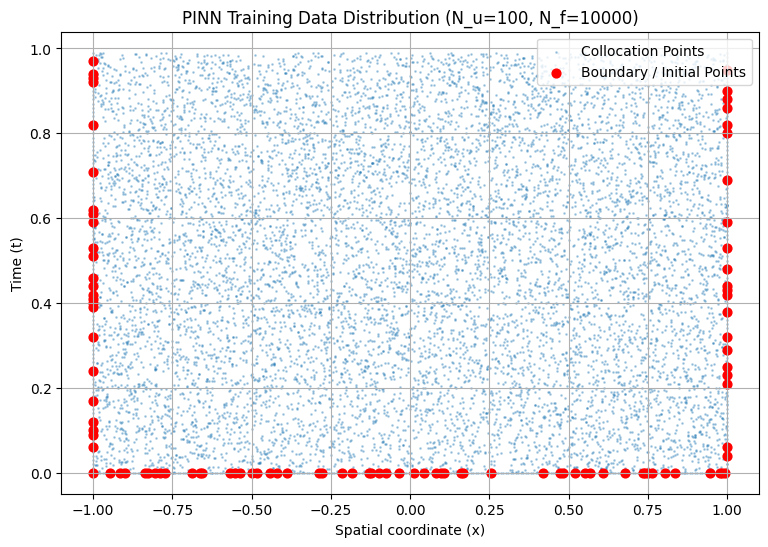

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(X_f_train[:,0], X_f_train[:,1], s=1, alpha=0.3, label="Collocation Points")
plt.scatter(X_u_train[:,0], X_u_train[:,1], s=40, color="red", label="Boundary / Initial Points")

plt.xlabel("Spatial coordinate (x)")
plt.ylabel("Time (t)")
plt.title(f"PINN Training Data Distribution (N_u={N_u}, N_f={N_f})")
plt.legend()
plt.grid(True)

plt.show()

# **Model parameter summary**

In [ ]:
!pip install torchinfo
from torchinfo import summary

# create your neural network
model = DNN(layers).to(device)

# print summary
summary(model, input_size=(1,2))

Layer (type:depth-idx)                   Output Shape              Param #
DNN                                      [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 20]                   60
│    └─Tanh: 2-2                         [1, 20]                   --
│    └─Linear: 2-3                       [1, 20]                   420
│    └─Tanh: 2-4                         [1, 20]                   --
│    └─Linear: 2-5                       [1, 20]                   420
│    └─Tanh: 2-6                         [1, 20]                   --
│    └─Linear: 2-7                       [1, 20]                   420
│    └─Tanh: 2-8                         [1, 20]                   --
│    └─Linear: 2-9                       [1, 20]                   420
│    └─Tanh: 2-10                        [1, 20]                   --
│    └─Linear: 2-11                      [1, 20]                   420
│    └─Tan

# **Summary of weight and bias and total number of parameter**

In [ ]:
# install torchinfo library
# torchinfo is used in PyTorch to print model architecture summary
# similar to model.summary() in Keras
!pip install torchinfo

# import summary function from torchinfo
from torchinfo import summary

# create the neural network model using defined architecture
# DNN(layers) builds the network based on the layers list
# .to(device) moves the model to GPU if available, otherwise CPU
model = DNN(layers).to(device)

# print model architecture summary
# input_size=(1,2) means batch size 1 and 2 input variables (x,t)
summary(model, input_size=(1,2))


# ------------------------------------------------------
# count total parameters, weights, and biases separately
# ------------------------------------------------------

total_params = 0
weight_params = 0
bias_params = 0

for name, param in model.named_parameters():

    if param.requires_grad:  # only count trainable parameters

        param_count = param.numel()
        total_params += param_count

        # check whether parameter is weight or bias
        if "weight" in name:
            weight_params += param_count
        elif "bias" in name:
            bias_params += param_count


# print parameter statistics
print("\nParameter Statistics")
print("-----------------------------")
print(f"Total Trainable Parameters : {total_params}")
print(f"Weight Parameters          : {weight_params}")
print(f"Bias Parameters            : {bias_params}")


Parameter Statistics
-----------------------------
Total Trainable Parameters : 3021
Weight Parameters          : 2860
Bias Parameters            : 161


# **Check GPU is available or not?**

In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA Available: True
GPU Name: Tesla T4


# **Model visualization**

In [ ]:
# -------------------------------------------------------------
# Create the Physics-Informed Neural Network (PINN) model
# -------------------------------------------------------------

# PhysicsInformedNN is the main class that implements the PINN
# It combines:
# 1) Neural Network approximation
# 2) PDE physics constraint (Burgers equation)
# 3) Boundary and initial condition data

# X_u_train  → coordinates of boundary/initial condition points (x,t)
# u_train    → known solution values at those boundary points
# X_f_train  → collocation points inside the domain for enforcing PDE residual
# layers     → neural network architecture [2,20,20,...,1]
# lb, ub     → lower and upper bounds of the computational domain
# nu         → viscosity coefficient in Burgers equation

# The model internally moves tensors and the neural network to
# GPU if CUDA is available, otherwise it runs on CPU

model = PhysicsInformedNN(
    X_u_train,   # boundary/initial condition coordinates
    u_train,     # corresponding solution values
    X_f_train,   # collocation points for physics loss
    layers,      # neural network layer configuration
    lb,          # lower domain bound
    ub,          # upper domain bound
    nu           # viscosity parameter
)
model.dnn.to(device)
# After this step:
# - the PINN neural network is initialized
# - model parameters are created
# - optimizer (LBFGS) is configured
# - training can start using model.train()

DNN(
  (layers): Sequential(
    (layer_0): Linear(in_features=2, out_features=20, bias=True)
    (activation_0): Tanh()
    (layer_1): Linear(in_features=20, out_features=20, bias=True)
    (activation_1): Tanh()
    (layer_2): Linear(in_features=20, out_features=20, bias=True)
    (activation_2): Tanh()
    (layer_3): Linear(in_features=20, out_features=20, bias=True)
    (activation_3): Tanh()
    (layer_4): Linear(in_features=20, out_features=20, bias=True)
    (activation_4): Tanh()
    (layer_5): Linear(in_features=20, out_features=20, bias=True)
    (activation_5): Tanh()
    (layer_6): Linear(in_features=20, out_features=20, bias=True)
    (activation_6): Tanh()
    (layer_7): Linear(in_features=20, out_features=20, bias=True)
    (activation_7): Tanh()
    (layer_8): Linear(in_features=20, out_features=1, bias=True)
  )
)

# **Simple check out which cuda is uitilize for multiple GPU user purpose**

In [ ]:
print(next(model.dnn.parameters()).device)

cuda:0


# **It's time to train the model!!**

In [ ]:
# -------------------------------------------------------------
# Train the Physics-Informed Neural Network (PINN)
# -------------------------------------------------------------

import time

# print which device is used
print("Training will run on:", device)

# start timer
start_time = time.time()

# train the model
# training runs on GPU if CUDA is available
# otherwise it automatically runs on CPU
model.train()

# end timer
end_time = time.time()

# print total training time
print("Training time:", end_time - start_time, "seconds")

Training will run on: cuda


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Iter 100, Loss: 8.85238e-02, Loss_u: 6.10823e-02, Loss_f: 2.74414e-02
Iter 200, Loss: 6.41117e-02, Loss_u: 4.41647e-02, Loss_f: 1.99470e-02
Iter 300, Loss: 4.77968e-02, Loss_u: 3.31503e-02, Loss_f: 1.46465e-02
Iter 400, Loss: 3.61981e-02, Loss_u: 2.51807e-02, Loss_f: 1.10173e-02
Iter 500, Loss: 2.88677e-02, Loss_u: 1.95637e-02, Loss_f: 9.30404e-03
Iter 600, Loss: 2.46192e-02, Loss_u: 1.64246e-02, Loss_f: 8.19452e-03
Iter 700, Loss: 2.07059e-02, Loss_u: 1.38709e-02, Loss_f: 6.83502e-03
Iter 800, Loss: 1.72197e-02, Loss_u: 1.06340e-02, Loss_f: 6.58565e-03
Iter 900, Loss: 1.27461e-02, Loss_u: 6.82282e-03, Loss_f: 5.92328e-03
Iter 1000, Loss: 1.05577e-02, Loss_u: 5.21953e-03, Loss_f: 5.33815e-03
Iter 1100, Loss: 7.89394e-03, Loss_u: 3.71905e-03, Loss_f: 4.17489e-03
Iter 1200, Loss: 6.10885e-03, Loss_u: 2.42886e-03, Loss_f: 3.67998e-03
Iter 1300, Loss: 4.38094e-03, Loss_u: 1.76342e-03, Loss_f: 2.61752e-03
Iter 1400, Loss: 3.22627e-03, Loss_u: 1.37953e-03, Loss_f: 1.84674e-03
Iter 1500, Loss

# **Now plot the all loss with respect to epoch okay!**

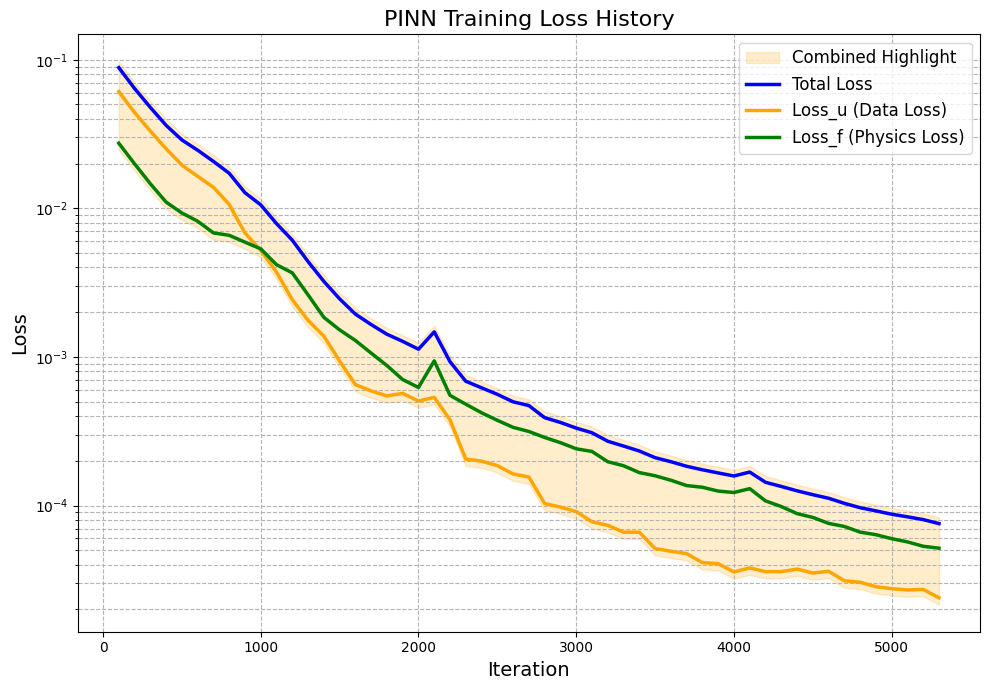

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Disable LaTeX dependency
plt.rcParams['text.usetex'] = False

fig, ax = plt.subplots(figsize=(10, 7)) # Use subplots for better control and increase figure size

# Convert lists to numpy arrays for calculation
iter_history_arr = np.array(model.iter_history)
loss_total_arr = np.array(model.loss_total)
loss_u_history_arr = np.array(model.loss_u_history)
loss_f_history_arr = np.array(model.loss_f_history)

# Stack all loss histories to find the min and max across all curves at each iteration
all_losses_stacked = np.vstack([loss_total_arr, loss_u_history_arr, loss_f_history_arr])
y_min_across_curves = np.min(all_losses_stacked, axis=0)
y_max_across_curves = np.max(all_losses_stacked, axis=0)

# Apply a small buffer to extend the shaded area (for log scale, multiplicative factor works well)
y_min_extended = y_min_across_curves * 0.9 # Extend downwards
y_max_extended = y_max_across_curves * 1.1 # Extend upwards

# Add a single common shaded area using light orange, with increased alpha
ax.fill_between(iter_history_arr, y_min_extended, y_max_extended, color='orange', alpha=0.2, label='Combined Highlight')

# Plot individual Loss curves (on top of the shaded area)
ax.plot(model.iter_history, model.loss_total, label='Total Loss', color='blue', linewidth=2.5)
ax.plot(model.iter_history, model.loss_u_history, label='Loss_u (Data Loss)', color='orange', linewidth=2.5)
ax.plot(model.iter_history, model.loss_f_history, label='Loss_f (Physics Loss)', color='green', linewidth=2.5)


ax.set_xlabel("Iteration", fontsize=14)
ax.set_ylabel("Loss", fontsize=14)
ax.set_title("PINN Training Loss History", fontsize=16)

ax.set_yscale("log")   # better for PINN loss visualization

ax.legend(fontsize=12)
ax.grid(True, which="both", ls="--", c='0.7') # Enhanced gridlines

plt.tight_layout() # Ensure all elements fit
plt.show()

# **Check performance of model**

In [ ]:
u_pred, f_pred = model.predict(X_star)

error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
print('Relative Error u: %e' % (error_u))

U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
Error = np.abs(Exact - U_pred)

Relative Error u: 4.467742e-02


# **Visualization**

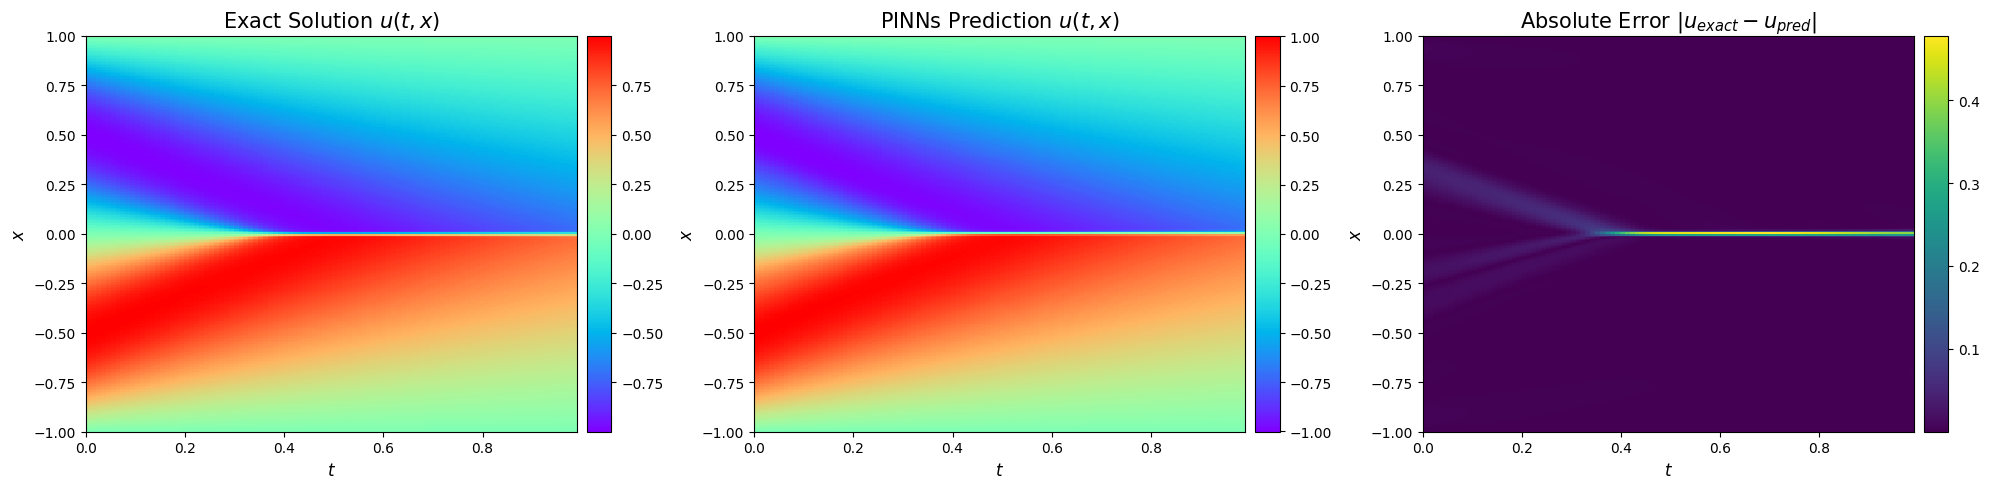

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Exact Solution Plot
h_exact = ax[0].imshow(Exact.T, interpolation='nearest', cmap='rainbow',
                   extent=[t.min(), t.max(), x.min(), x.max()],
                   origin='lower', aspect='auto')
divider_exact = make_axes_locatable(ax[0])
cax_exact = divider_exact.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_exact, cax=cax_exact)
ax[0].set_title('Exact Solution $u(t,x)$', fontsize=15)
ax[0].set_xlabel('$t$', fontsize=12)
ax[0].set_ylabel('$x$', fontsize=12)
ax[0].tick_params(labelsize=10)

# PINNs Prediction Plot
h_pred = ax[1].imshow(U_pred.T, interpolation='nearest', cmap='rainbow',
                  extent=[t.min(), t.max(), x.min(), x.max()],
                  origin='lower', aspect='auto')
divider_pred = make_axes_locatable(ax[1])
cax_pred = divider_pred.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_pred, cax=cax_pred)
ax[1].set_title('PINNs Prediction $u(t,x)$', fontsize=15)
ax[1].set_xlabel('$t$', fontsize=12)
ax[1].set_ylabel('$x$', fontsize=12)
ax[1].tick_params(labelsize=10)

# Absolute Error Plot
h_error = ax[2].imshow(Error.T, interpolation='nearest', cmap='viridis',
                   extent=[t.min(), t.max(), x.min(), x.max()],
                   origin='lower', aspect='auto')
divider_error = make_axes_locatable(ax[2])
cax_error = divider_error.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_error, cax=cax_error)
ax[2].set_title('Absolute Error $|u_{exact} - u_{pred}|$', fontsize=15)
ax[2].set_xlabel('$t$', fontsize=12)
ax[2].set_ylabel('$x$', fontsize=12)
ax[2].tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# **Shock capture different time step**

/tmp/ipykernel_8905/1925125509.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


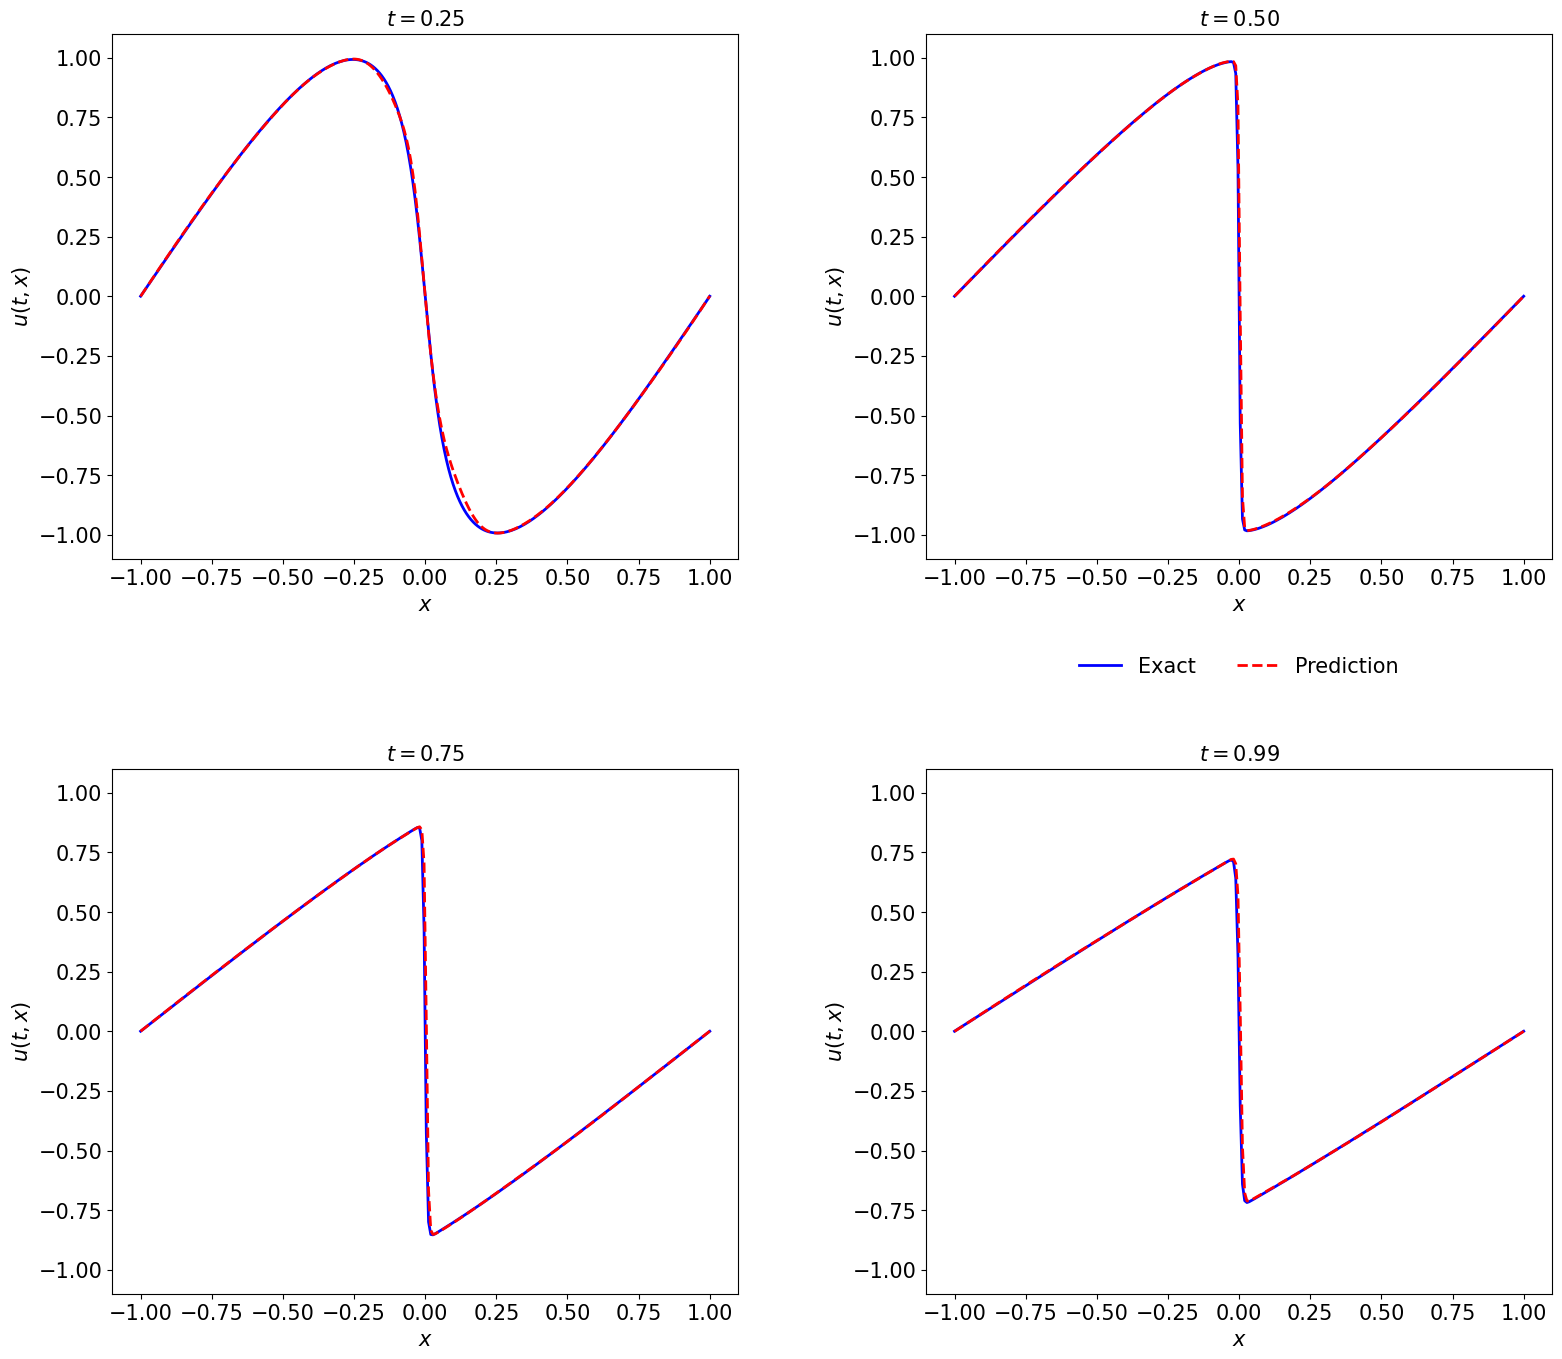

In [ ]:
# Row 1: u(t,x) slices ##################

""" The aesthetic setting has changed. """

fig = plt.figure(figsize=(18, 14)) # Increased figure size

gs1 = gridspec.GridSpec(2, 2) # Changed to 2 rows, 2 columns
gs1.update(top=0.95, bottom=0.05, left=0.1, right=0.9, wspace=0.3, hspace=0.4) # Adjusted update parameters for 2x2 grid

ax = plt.subplot(gs1[0, 0])
ax.plot(x,Exact[25,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[25,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
ax.set_title('$t = 0.25$', fontsize = 15)
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

ax = plt.subplot(gs1[0, 1])
ax.plot(x,Exact[50,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[50,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.50$', fontsize = 15)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
    prop={'size': 15}
)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

ax = plt.subplot(gs1[1, 0]) # Changed index to second row, first column
ax.plot(x,Exact[75,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[75,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.75$', fontsize = 15)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

# New subplot for t = 0.99
ax = plt.subplot(gs1[1, 1]) # Second row, second column
ax.plot(x,Exact[99,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[99,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.99$', fontsize = 15)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.tight_layout()
plt.show()

# **Implementation of Weighted Loss Function**

To investigate the impact of loss term weighting on the training progression, this implementation introduces an adjustment to the overall loss function. Specifically, the weight for $Loss_u$ (data loss) is set to 1, while the weight for $Loss_f$ (physics loss) is set to 3. The objective is to observe the resulting convergence behavior and loss dynamics under this adjusted weighting scheme.

In [ ]:
import torch
from collections import OrderedDict

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
# from plotting import newfig, savefig
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import time

np.random.seed(1234)

# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
# the deep neural network
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out
# the physics-guided neural network
class PhysicsInformedNN():
    def __init__(self, X_u, u, X_f, layers, lb, ub, nu):

        # boundary conditions
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        # data
        self.x_u = torch.tensor(X_u[:, 0:1], requires_grad=True).float().to(device)
        self.t_u = torch.tensor(X_u[:, 1:2], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.u = torch.tensor(u).float().to(device)

        self.layers = layers
        self.nu = nu

        # deep neural networks
        self.dnn = DNN(layers).to(device)

        # optimizers: using the same settings
        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"       # can be "strong_wolfe"
        )

        self.iter = 0

    def net_u(self, x, t):
        u = self.dnn(torch.cat([x, t], dim=1))
        return u

    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t)

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]

        f = u_t + u * u_x - self.nu * u_xx
        return f

    def loss_func(self):
        self.optimizer.zero_grad()

        u_pred = self.net_u(self.x_u, self.t_u)
        f_pred = self.net_f(self.x_f, self.t_f)
        loss_u = torch.mean((self.u - u_pred) ** 2)
        loss_f = torch.mean(f_pred ** 2)

        loss = loss_u + 3*loss_f

        loss.backward()
        self.iter += 1
        if self.iter % 100 == 0:
            print(
                'Iter %d, Loss: %.5e, Loss_u: %.5e, Loss_f: %.5e' % (self.iter, loss.item(), loss_u.item(), loss_f.item())
            )
        return loss

    def train(self):
        self.dnn.train()

        # Backward and optimize
        self.optimizer.step(self.loss_func)


    def predict(self, X):
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device)
        t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)

        self.dnn.eval()
        u = self.net_u(x, t)
        f = self.net_f(x, t)
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy()
        return u, f
nu = 0.01/np.pi
noise = 0.0

N_u = 100
N_f = 10000
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

data = scipy.io.loadmat('/content/data/burgers_shock.mat')

t = data['t'].flatten()[:,None]
x = data['x'].flatten()[:,None]
Exact = np.real(data['usol']).T

X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
u_star = Exact.flatten()[:,None]

# Doman bounds
lb = X_star.min(0)
ub = X_star.max(0)

xx1 = np.hstack((X[0:1,:].T, T[0:1,:].T))
uu1 = Exact[0:1,:].T
xx2 = np.hstack((X[:,0:1], T[:,0:1]))
uu2 = Exact[:,0:1]
xx3 = np.hstack((X[:,-1:], T[:,-1:]))
uu3 = Exact[:,-1:]

X_u_train = np.vstack([xx1, xx2, xx3])
X_f_train = lb + (ub-lb)*lhs(2, N_f)
X_f_train = np.vstack((X_f_train, X_u_train))
u_train = np.vstack([uu1, uu2, uu3])

idx = np.random.choice(X_u_train.shape[0], N_u, replace=False)
X_u_train = X_u_train[idx, :]
u_train = u_train[idx,:]


model = PhysicsInformedNN(X_u_train, u_train, X_f_train, layers, lb, ub, nu)

model.dnn = model.dnn.to(device)

# -------------------------------------------------------------
# Train the Physics-Informed Neural Network (PINN)
# -------------------------------------------------------------

import time

# print which device is used
print("Training will run on:", device)

# start timer
start_time = time.time()

# train the model
# training runs on GPU if CUDA is available
# otherwise it automatically runs on CPU
model.train()

# end timer
end_time = time.time()

# print total training time
print("Training time:", end_time - start_time, "seconds")

Training will run on: cuda
Iter 100, Loss: 1.22033e-01, Loss_u: 9.95151e-02, Loss_f: 7.50605e-03
Iter 200, Loss: 7.15748e-02, Loss_u: 5.71829e-02, Loss_f: 4.79730e-03
Iter 300, Loss: 4.71281e-02, Loss_u: 3.75643e-02, Loss_f: 3.18793e-03
Iter 400, Loss: 3.75754e-02, Loss_u: 2.88069e-02, Loss_f: 2.92284e-03
Iter 500, Loss: 2.64760e-02, Loss_u: 1.84070e-02, Loss_f: 2.68969e-03
Iter 600, Loss: 1.66752e-02, Loss_u: 9.42695e-03, Loss_f: 2.41608e-03
Iter 700, Loss: 1.06774e-02, Loss_u: 5.08863e-03, Loss_f: 1.86291e-03
Iter 800, Loss: 7.44779e-03, Loss_u: 3.61221e-03, Loss_f: 1.27852e-03
Iter 900, Loss: 5.10862e-03, Loss_u: 1.90713e-03, Loss_f: 1.06716e-03
Iter 1000, Loss: 3.62620e-03, Loss_u: 1.09570e-03, Loss_f: 8.43500e-04
Iter 1100, Loss: 2.67344e-03, Loss_u: 7.64093e-04, Loss_f: 6.36449e-04
Iter 1200, Loss: 2.01666e-03, Loss_u: 5.42420e-04, Loss_f: 4.91413e-04
Iter 1300, Loss: 1.53605e-03, Loss_u: 4.15095e-04, Loss_f: 3.73651e-04
Iter 1400, Loss: 1.19058e-03, Loss_u: 2.96454e-04, Loss_f: 

# **Check performance**

In [ ]:
u_pred, f_pred = model.predict(X_star)

error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
print('Relative Error u: %e' % (error_u))

U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
Error = np.abs(Exact - U_pred)

Relative Error u: 8.748830e-03


# **Visualization**

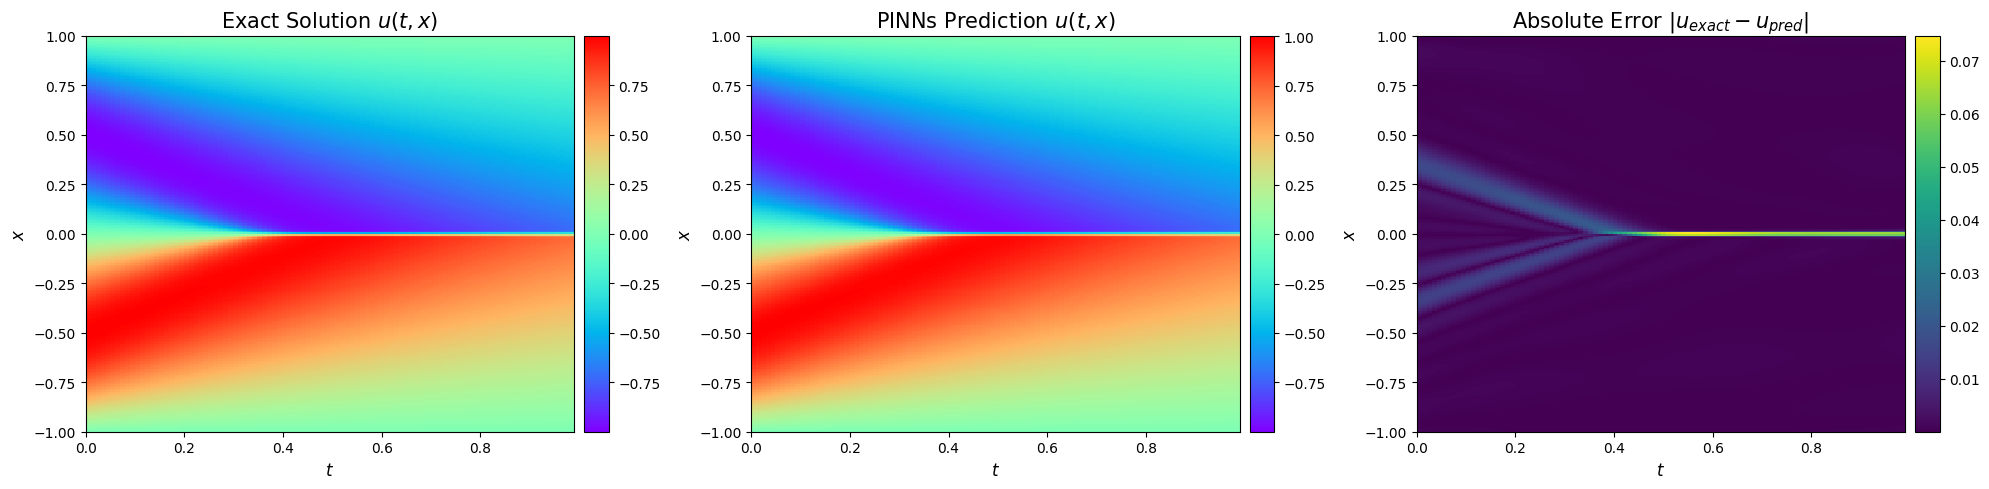

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Exact Solution Plot
h_exact = ax[0].imshow(Exact.T, interpolation='nearest', cmap='rainbow',
                   extent=[t.min(), t.max(), x.min(), x.max()],
                   origin='lower', aspect='auto')
divider_exact = make_axes_locatable(ax[0])
cax_exact = divider_exact.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_exact, cax=cax_exact)
ax[0].set_title('Exact Solution $u(t,x)$', fontsize=15)
ax[0].set_xlabel('$t$', fontsize=12)
ax[0].set_ylabel('$x$', fontsize=12)
ax[0].tick_params(labelsize=10)

# PINNs Prediction Plot
h_pred = ax[1].imshow(U_pred.T, interpolation='nearest', cmap='rainbow',
                  extent=[t.min(), t.max(), x.min(), x.max()],
                  origin='lower', aspect='auto')
divider_pred = make_axes_locatable(ax[1])
cax_pred = divider_pred.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_pred, cax=cax_pred)
ax[1].set_title('PINNs Prediction $u(t,x)$', fontsize=15)
ax[1].set_xlabel('$t$', fontsize=12)
ax[1].set_ylabel('$x$', fontsize=12)
ax[1].tick_params(labelsize=10)

# Absolute Error Plot
h_error = ax[2].imshow(Error.T, interpolation='nearest', cmap='viridis',
                   extent=[t.min(), t.max(), x.min(), x.max()],
                   origin='lower', aspect='auto')
divider_error = make_axes_locatable(ax[2])
cax_error = divider_error.append_axes("right", size="5%", pad=0.10)
fig.colorbar(h_error, cax=cax_error)
ax[2].set_title('Absolute Error $|u_{exact} - u_{pred}|$', fontsize=15)
ax[2].set_xlabel('$t$', fontsize=12)
ax[2].set_ylabel('$x$', fontsize=12)
ax[2].tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# **Shock evolution**

/tmp/ipykernel_8905/1925125509.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


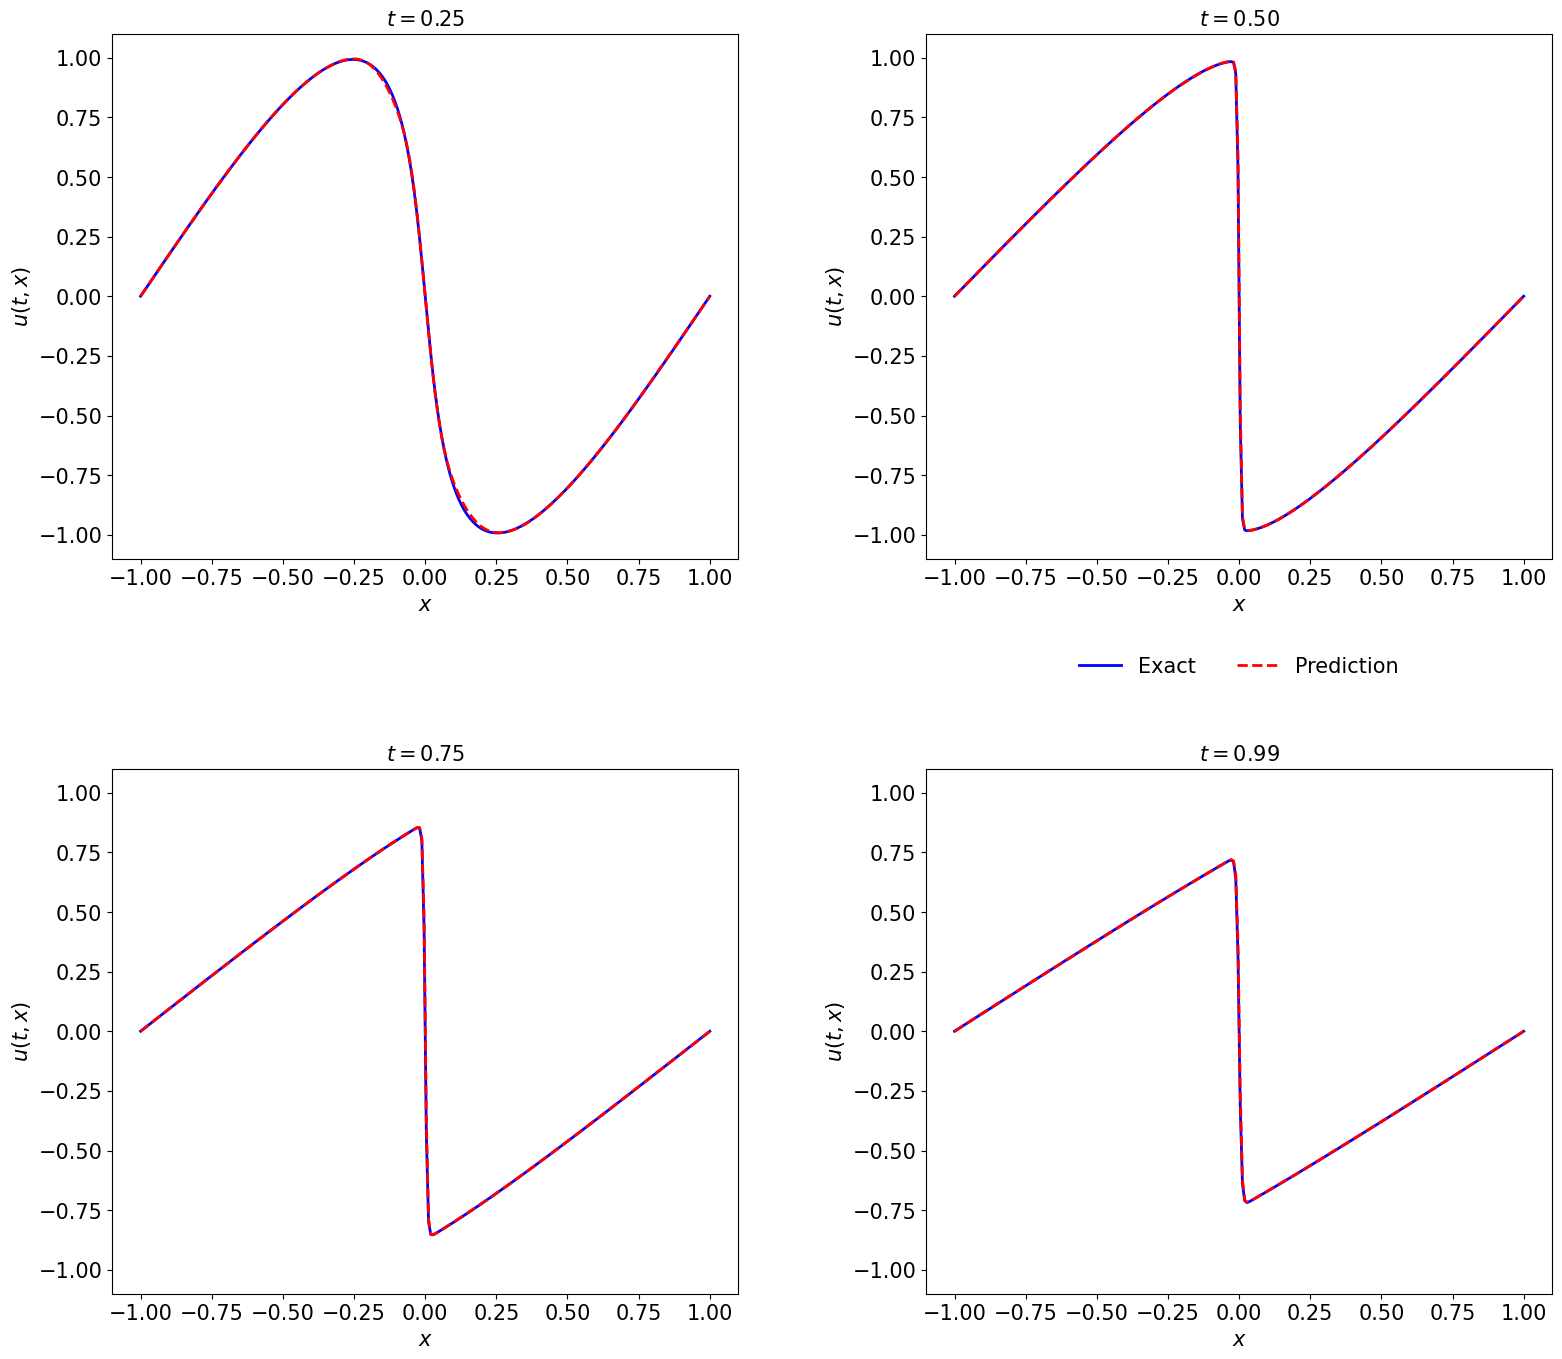

In [ ]:
# Row 1: u(t,x) slices ##################

""" The aesthetic setting has changed. """

fig = plt.figure(figsize=(18, 14)) # Increased figure size

gs1 = gridspec.GridSpec(2, 2) # Changed to 2 rows, 2 columns
gs1.update(top=0.95, bottom=0.05, left=0.1, right=0.9, wspace=0.3, hspace=0.4) # Adjusted update parameters for 2x2 grid

ax = plt.subplot(gs1[0, 0])
ax.plot(x,Exact[25,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[25,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
ax.set_title('$t = 0.25$', fontsize = 15)
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

ax = plt.subplot(gs1[0, 1])
ax.plot(x,Exact[50,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[50,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.50$', fontsize = 15)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
    prop={'size': 15}
)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

ax = plt.subplot(gs1[1, 0]) # Changed index to second row, first column
ax.plot(x,Exact[75,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[75,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.75$', fontsize = 15)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

# New subplot for t = 0.99
ax = plt.subplot(gs1[1, 1]) # Second row, second column
ax.plot(x,Exact[99,:], 'b-', linewidth = 2, label = 'Exact')
ax.plot(x,U_pred[99,:], 'r--', linewidth = 2, label = 'Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
# ax.axis('square') # Removed for better x-axis spacing
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_title('$t = 0.99$', fontsize = 15)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.tight_layout()
plt.show()

# **Properties of Dynamically Learned Loss Weights**

The implementation uses two independent trainable parameters, $w_1^{raw}$ and $w_2^{raw}$, which are transformed using the sigmoid function to obtain the actual loss weights, $w_1$ and $w_2$. This design ensures several desirable properties:

*   **Always Positive**: The sigmoid function, $\sigma(z) = \frac{1}{1 + e^{-z}}$, maps any real number $z$ to a value strictly between 0 and 1. Consequently, $w_1 = \sigma(w_1^{raw})$ and $w_2 = \sigma(w_2^{raw})$ are always positive ($w_1, w_2 > 0$).
*   **Always Less Than 1**: As a direct result of the sigmoid function's properties, both $w_1$ and $w_2$ will always be less than 1 ($w_1, w_2 < 1$).
*   **Start Equal at 0.5**: Both $w_1^{raw}$ and $w_2^{raw}$ are initialized to 0. Since $\sigma(0) = 0.5$, both $w_1$ and $w_2$ will start their training at an equal value of 0.5, implying an initial balanced weighting of the loss components.
*   **Fully Differentiable**: The sigmoid function is smooth and differentiable across its entire domain. This ensures that the gradients with respect to $w_1^{raw}$ and $w_2^{raw}$ can be computed seamlessly during backpropagation, allowing them to be optimized efficiently.
*   **No Constraint Between $w_1$ and $w_2$**: Unlike convex combination schemes where weights must sum to a constant (e.g., 1), $w_1$ and $w_2$ are derived from independent raw parameters. This means there is no explicit constraint linking their values, allowing them to adjust freely and independently of each other during training.
*   **Adjusts Like Network Weights**: Since $w_1^{raw}$ and $w_2^{raw}$ are declared as `torch.nn.Parameter` and included in the optimizer's parameter list, they are optimized alongside the neural network's weights and biases. They are updated based on the gradients of the total loss, adapting dynamically to the training process.


Training will run on: cuda

Phase 1 : Adam warm-up (10000 epochs)
Epoch   1000 | Loss: 1.262e-02 | Loss_u: 2.359e-02 | Loss_f: 1.323e-02 | w1: 0.3642 | w2: 0.3040 | LR: 9.76e-04
Epoch   2000 | Loss: 4.147e-03 | Loss_u: 8.591e-03 | Loss_f: 7.838e-03 | w1: 0.2934 | w2: 0.2075 | LR: 9.05e-04
Epoch   3000 | Loss: 2.717e-03 | Loss_u: 2.548e-03 | Loss_f: 1.321e-02 | w1: 0.2629 | w2: 0.1551 | LR: 7.96e-04
Epoch   4000 | Loss: 5.624e-04 | Loss_u: 8.561e-04 | Loss_f: 2.681e-03 | w1: 0.2512 | w2: 0.1296 | LR: 6.58e-04
Epoch   5000 | Loss: 3.249e-04 | Loss_u: 4.777e-04 | Loss_f: 1.820e-03 | w1: 0.2447 | w2: 0.1143 | LR: 5.05e-04
Epoch   6000 | Loss: 2.250e-04 | Loss_u: 3.202e-04 | Loss_f: 1.414e-03 | w1: 0.2400 | w2: 0.1047 | LR: 3.52e-04
Epoch   7000 | Loss: 1.628e-04 | Loss_u: 2.390e-04 | Loss_f: 1.082e-03 | w1: 0.2365 | w2: 0.0983 | LR: 2.14e-04
Epoch   8000 | Loss: 1.253e-04 | Loss_u: 1.778e-04 | Loss_f: 8.896e-04 | w1: 0.2342 | w2: 0.0941 | LR: 1.05e-04
Epoch   9000 | Loss: 1.096e-04 | Loss

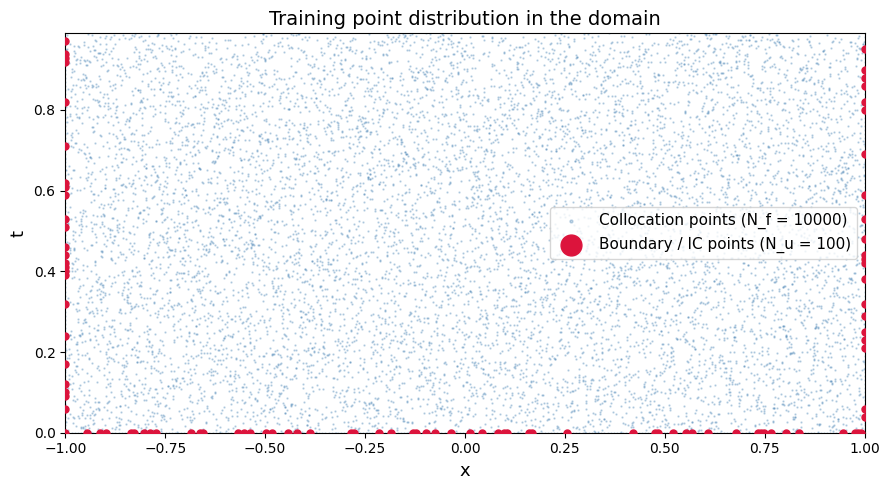

Plot 1 saved.


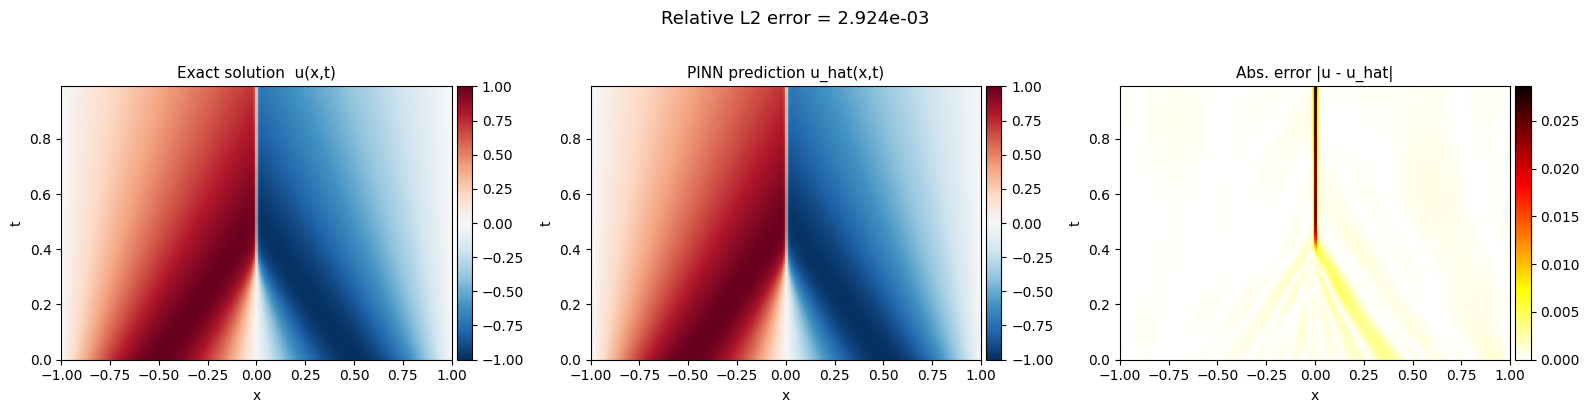

Plot 2 saved.


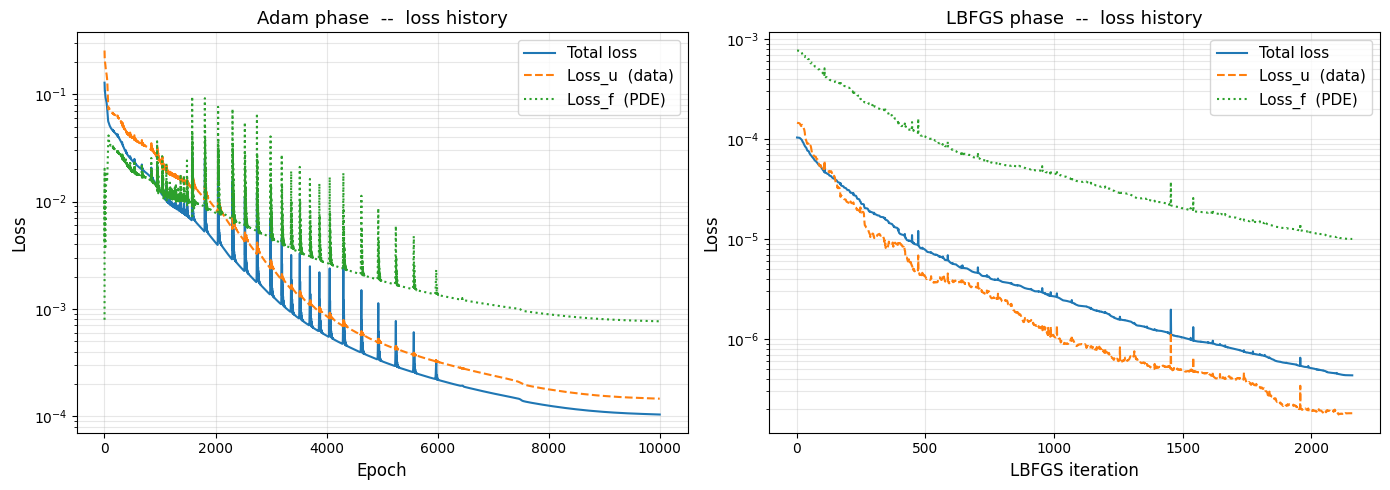

Plot 3 saved.


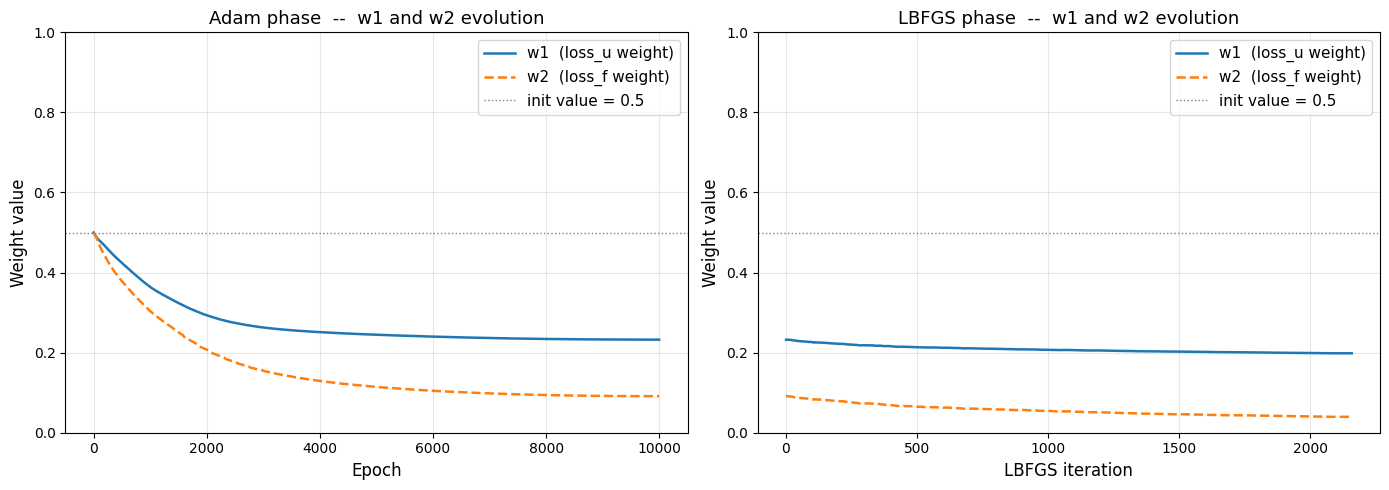

Plot 4 saved.


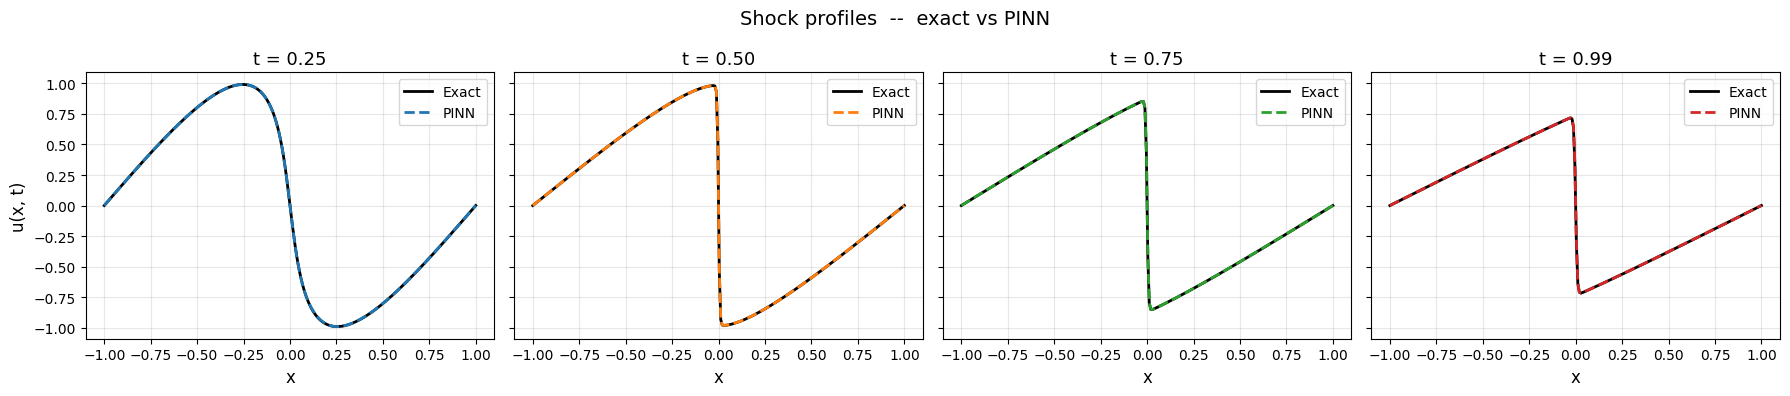

Plot 5 saved.


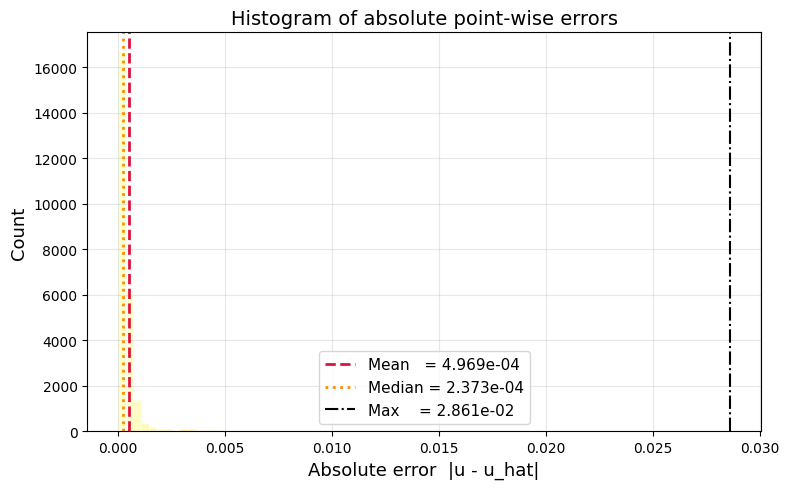

Plot 6 saved.
Plot 7 animation saved -> plot7_shock_animation.gif


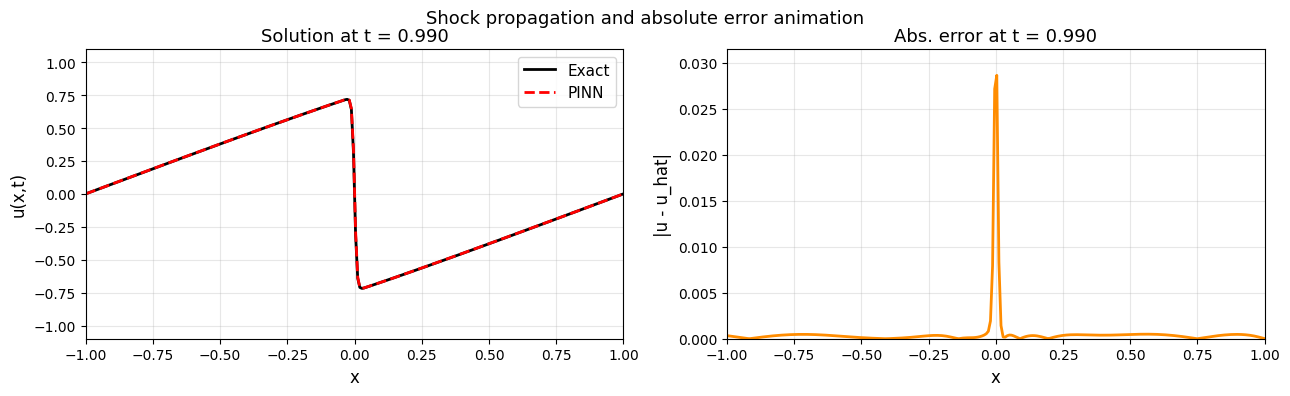

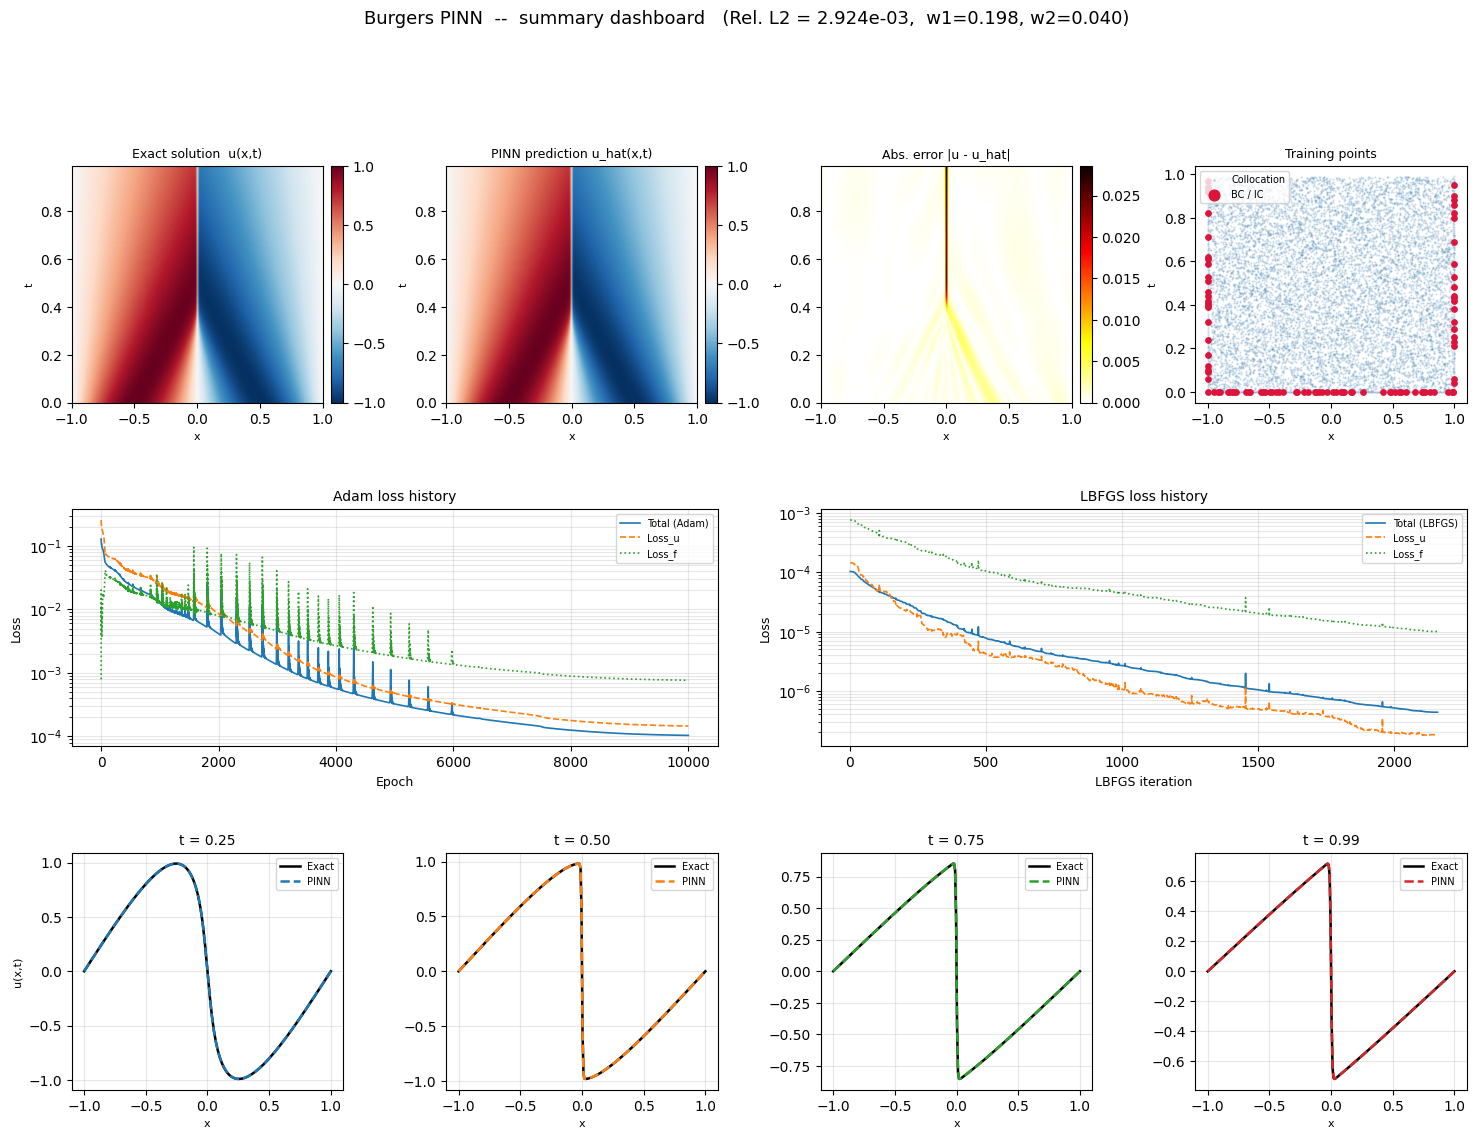

Plot 8 saved.

All 8 plots saved successfully.


In [ ]:
import torch
from collections import OrderedDict
from pyDOE import lhs
import numpy as np
import scipy.io
import time
import matplotlib
matplotlib.rcParams['text.usetex']      = False
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(1234)
torch.manual_seed(1234)

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


# -----------------------------------------------------------------------
# Deep Neural Network
# -----------------------------------------------------------------------
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()
        self.depth      = len(layers) - 1
        self.activation = torch.nn.Tanh

        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(('layer_%d'      % i, torch.nn.Linear(layers[i], layers[i+1])))
            layer_list.append(('activation_%d' % i, self.activation()))
        layer_list.append(('layer_%d' % (self.depth - 1),
                            torch.nn.Linear(layers[-2], layers[-1])))
        self.layers = torch.nn.Sequential(OrderedDict(layer_list))

        for m in self.layers.modules():
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.layers(x)


# -----------------------------------------------------------------------
# Physics-Informed Neural Network
# -----------------------------------------------------------------------
class PhysicsInformedNN():
    def __init__(self, X_u, u, X_f, layers, lb, ub, nu):

        self.lb  = torch.tensor(lb).float().to(device)
        self.ub  = torch.tensor(ub).float().to(device)
        self.nu  = nu

        self.x_u = torch.tensor(X_u[:, 0:1], requires_grad=True).float().to(device)
        self.t_u = torch.tensor(X_u[:, 1:2], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.u   = torch.tensor(u).float().to(device)

        self.layers = layers
        self.dnn    = DNN(layers).to(device)

        # ----------------------------------------------------------------
        # Two independent trainable weights, each in (0, 1)
        #
        # Store raw unconstrained scalars w1_raw, w2_raw.
        # Recover actual weights via sigmoid:
        #
        #   w1 = sigmoid(w1_raw)   in (0, 1)  always
        #   w2 = sigmoid(w2_raw)   in (0, 1)  always
        #
        # Both start at sigmoid(0) = 0.5
        # They are completely independent — no constraint between them.
        # No convex combination, no sum-to-one rule.
        # They adjust freely during training just like network weights.
        # ----------------------------------------------------------------
        self.w1_raw = torch.nn.Parameter(torch.zeros(1, device=device))
        self.w2_raw = torch.nn.Parameter(torch.zeros(1, device=device))

        all_params = (list(self.dnn.parameters())
                      + [self.w1_raw, self.w2_raw])

        self.optimizer_adam = torch.optim.Adam(all_params, lr=1e-3)
        self.scheduler      = torch.optim.lr_scheduler.CosineAnnealingLR(
                                  self.optimizer_adam, T_max=10000, eta_min=1e-5)

        self.optimizer_lbfgs = torch.optim.LBFGS(
            all_params,
            lr               = 1.0,
            max_iter         = 100000,
            max_eval         = 100000,
            history_size     = 100,
            tolerance_grad   = 1e-9,
            tolerance_change = 1e-12,
            line_search_fn   = "strong_wolfe"
        )

        self.iter = 0

        # history buffers
        self.adam_loss_history   = []
        self.adam_loss_u_history = []
        self.adam_loss_f_history = []
        self.adam_w1_history     = []
        self.adam_w2_history     = []

        self.lbfgs_loss_history   = []
        self.lbfgs_loss_u_history = []
        self.lbfgs_loss_f_history = []
        self.lbfgs_w1_history     = []
        self.lbfgs_w2_history     = []

    # ------------------------------------------------------------------
    def _normalise(self, x, t):
        x_n = 2.0 * (x - self.lb[0]) / (self.ub[0] - self.lb[0]) - 1.0
        t_n = 2.0 * (t - self.lb[1]) / (self.ub[1] - self.lb[1]) - 1.0
        return x_n, t_n

    def net_u(self, x, t):
        x_n, t_n = self._normalise(x, t)
        return self.dnn(torch.cat([x_n, t_n], dim=1))

    def net_f(self, x, t):
        u    = self.net_u(x, t)
        u_t  = torch.autograd.grad(u,   t,   grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        u_x  = torch.autograd.grad(u,   x,   grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x,   grad_outputs=torch.ones_like(u_x),
                                   retain_graph=True, create_graph=True)[0]
        return u_t + u * u_x - self.nu * u_xx

    # ------------------------------------------------------------------
    # Loss with two independent sigmoid weights
    # ------------------------------------------------------------------
    def compute_loss(self):
        u_pred = self.net_u(self.x_u, self.t_u)
        f_pred = self.net_f(self.x_f, self.t_f)

        loss_u = torch.mean((self.u - u_pred) ** 2)
        loss_f = torch.mean(f_pred ** 2)

        # sigmoid maps any real number to (0, 1) — always positive,
        # always less than 1, fully differentiable, no clamping needed
        w1 = torch.sigmoid(self.w1_raw)   # weight for loss_u
        w2 = torch.sigmoid(self.w2_raw)   # weight for loss_f

        # weighted loss — w1 and w2 are independent, no sum constraint
        loss = w1 * loss_u + w2 * loss_f

        return loss, loss_u, loss_f, w1.item(), w2.item()

    # ------------------------------------------------------------------
    # LBFGS closure
    # ------------------------------------------------------------------
    def loss_func(self):
        self.optimizer_lbfgs.zero_grad()
        loss, loss_u, loss_f, w1, w2 = self.compute_loss()
        loss.backward()
        self.iter += 1

        self.lbfgs_loss_history.append(loss.item())
        self.lbfgs_loss_u_history.append(loss_u.item())
        self.lbfgs_loss_f_history.append(loss_f.item())
        self.lbfgs_w1_history.append(w1)
        self.lbfgs_w2_history.append(w2)

        if self.iter % 200 == 0:
            print('LBFGS Iter %6d | Loss: %.3e | Loss_u: %.3e | '
                  'Loss_f: %.3e | w1: %.4f | w2: %.4f'
                  % (self.iter, loss.item(), loss_u.item(),
                     loss_f.item(), w1, w2))
        return loss

    # ------------------------------------------------------------------
    # Phase 1 — Adam
    # ------------------------------------------------------------------
    def train_adam(self, n_epochs=10000):
        self.dnn.train()
        print("=" * 72)
        print("Phase 1 : Adam warm-up (%d epochs)" % n_epochs)
        print("=" * 72)
        for epoch in range(1, n_epochs + 1):
            self.optimizer_adam.zero_grad()
            loss, loss_u, loss_f, w1, w2 = self.compute_loss()
            loss.backward()
            self.optimizer_adam.step()
            self.scheduler.step()

            self.adam_loss_history.append(loss.item())
            self.adam_loss_u_history.append(loss_u.item())
            self.adam_loss_f_history.append(loss_f.item())
            self.adam_w1_history.append(w1)
            self.adam_w2_history.append(w2)

            if epoch % 1000 == 0:
                print('Epoch %6d | Loss: %.3e | Loss_u: %.3e | '
                      'Loss_f: %.3e | w1: %.4f | w2: %.4f | LR: %.2e'
                      % (epoch, loss.item(), loss_u.item(), loss_f.item(),
                         w1, w2, self.scheduler.get_last_lr()[0]))

    # ------------------------------------------------------------------
    # Phase 2 — LBFGS
    # ------------------------------------------------------------------
    def train_lbfgs(self):
        self.dnn.train()
        print("\n" + "=" * 72)
        print("Phase 2 : LBFGS fine-tuning")
        print("=" * 72)
        self.iter = 0
        self.optimizer_lbfgs.step(self.loss_func)

    # ------------------------------------------------------------------
    def predict(self, X):
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device)
        t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)
        self.dnn.eval()
        u = self.net_u(x, t)
        f = self.net_f(x, t)
        return u.detach().cpu().numpy(), f.detach().cpu().numpy()

    def get_weights(self):
        w1 = torch.sigmoid(self.w1_raw).item()
        w2 = torch.sigmoid(self.w2_raw).item()
        return w1, w2


# =======================================================================
# Data preparation
# =======================================================================
nu     = 0.01 / np.pi
N_u    = 100
N_f    = 10000
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

data  = scipy.io.loadmat('/content/data/burgers_shock.mat')
t_dat = data['t'].flatten()[:, None]
x_dat = data['x'].flatten()[:, None]
Exact = np.real(data['usol']).T

X, T   = np.meshgrid(x_dat, t_dat)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_star = Exact.flatten()[:, None]

lb = X_star.min(0)
ub = X_star.max(0)

xx1 = np.hstack((X[0:1, :].T, T[0:1, :].T));  uu1 = Exact[0:1, :].T
xx2 = np.hstack((X[:, 0:1],   T[:, 0:1]));    uu2 = Exact[:, 0:1]
xx3 = np.hstack((X[:, -1:],   T[:, -1:]));    uu3 = Exact[:, -1:]

X_u_train = np.vstack([xx1, xx2, xx3])
X_f_train = lb + (ub - lb) * lhs(2, N_f)
X_f_train = np.vstack((X_f_train, X_u_train))
u_train   = np.vstack([uu1, uu2, uu3])

idx       = np.random.choice(X_u_train.shape[0], N_u, replace=False)
X_u_train = X_u_train[idx, :]
u_train   = u_train[idx, :]


# =======================================================================
# Train
# =======================================================================
model = PhysicsInformedNN(X_u_train, u_train, X_f_train, layers, lb, ub, nu)
print(f"\nTraining will run on: {device}\n")

t0 = time.time()
model.train_adam(n_epochs=10000)
t1 = time.time()
print(f"\nAdam time  : {t1 - t0:.1f} s")

model.train_lbfgs()
t2 = time.time()
print(f"\nLBFGS time : {t2 - t1:.1f} s")

print("\n" + "=" * 72)
print(f"Total training time : {t2 - t0:.1f} s")
w1_final, w2_final = model.get_weights()
print(f"Final w1 (loss_u weight) : {w1_final:.6f}  -- always in (0, 1)")
print(f"Final w2 (loss_f weight) : {w2_final:.6f}  -- always in (0, 1)")
print("=" * 72)

u_pred, f_pred = model.predict(X_star)
error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
print(f"\nRelative L2 Error in u : {error_u:.5e}")

U_pred  = u_pred.reshape(len(t_dat), len(x_dat))
U_exact = Exact
U_error = np.abs(U_exact - U_pred)
x_flat  = x_dat.flatten()
t_flat  = t_dat.flatten()
vmin    = min(U_exact.min(), U_pred.min())
vmax    = max(U_exact.max(), U_pred.max())

adam_epochs = np.arange(1, len(model.adam_loss_history)  + 1)
lbfgs_iters = np.arange(1, len(model.lbfgs_loss_history) + 1)
t_targets   = [0.25, 0.50, 0.75, 0.99]
colors      = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
panels      = [
    (U_exact, 'Exact solution  u(x,t)',     'RdBu_r', vmin, vmax),
    (U_pred,  'PINN prediction u_hat(x,t)', 'RdBu_r', vmin, vmax),
    (U_error, 'Abs. error |u - u_hat|',     'hot_r',  0,    U_error.max()),
]


# =======================================================================
# PLOT 1: Training point distribution
# =======================================================================
fig1, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_f_train[:, 0], X_f_train[:, 1],
           s=0.5, c='steelblue', alpha=0.3,
           label='Collocation points (N_f = %d)' % N_f)
ax.scatter(X_u_train[:, 0], X_u_train[:, 1],
           s=25, c='crimson', zorder=5,
           label='Boundary / IC points (N_u = %d)' % N_u)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('t', fontsize=13)
ax.set_title('Training point distribution in the domain', fontsize=14)
ax.legend(fontsize=11, markerscale=3)
ax.set_xlim(lb[0], ub[0])
ax.set_ylim(lb[1], ub[1])
plt.tight_layout()
plt.savefig('plot1_training_points.png', dpi=150)
plt.show()
print("Plot 1 saved.")


# =======================================================================
# PLOT 2: Exact vs Predicted 2D + Absolute error
# =======================================================================
fig2, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (data2d, title, cmap_s, vn, vx) in zip(axes, panels):
    im = ax.imshow(data2d, aspect='auto', origin='lower',
                   extent=[x_flat.min(), x_flat.max(),
                           t_flat.min(), t_flat.max()],
                   cmap=cmap_s, vmin=vn, vmax=vx)
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('right', size='4%', pad=0.05)
    plt.colorbar(im, cax=cax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('t', fontsize=10)
plt.suptitle('Relative L2 error = %.3e' % error_u, fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot2_exact_pred_error.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")


# =======================================================================
# PLOT 3: Loss component history
# =======================================================================
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(adam_epochs, model.adam_loss_history,
            lw=1.5, label='Total loss')
ax.semilogy(adam_epochs, model.adam_loss_u_history,
            lw=1.5, ls='--', label='Loss_u  (data)')
ax.semilogy(adam_epochs, model.adam_loss_f_history,
            lw=1.5, ls=':', label='Loss_f  (PDE)')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Adam phase  --  loss history', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogy(lbfgs_iters, model.lbfgs_loss_history,
            lw=1.5, label='Total loss')
ax.semilogy(lbfgs_iters, model.lbfgs_loss_u_history,
            lw=1.5, ls='--', label='Loss_u  (data)')
ax.semilogy(lbfgs_iters, model.lbfgs_loss_f_history,
            lw=1.5, ls=':', label='Loss_f  (PDE)')
ax.set_xlabel('LBFGS iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('LBFGS phase  --  loss history', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_loss_history.png', dpi=150)
plt.show()
print("Plot 3 saved.")


# =======================================================================
# PLOT 4: Weight evolution
# =======================================================================
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(adam_epochs, model.adam_w1_history,
        lw=1.8, color='tab:blue',   label='w1  (loss_u weight)')
ax.plot(adam_epochs, model.adam_w2_history,
        lw=1.8, color='tab:orange', label='w2  (loss_f weight)', ls='--')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='init value = 0.5')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Weight value', fontsize=12)
ax.set_title('Adam phase  --  w1 and w2 evolution', fontsize=13)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lbfgs_iters, model.lbfgs_w1_history,
        lw=1.8, color='tab:blue',   label='w1  (loss_u weight)')
ax.plot(lbfgs_iters, model.lbfgs_w2_history,
        lw=1.8, color='tab:orange', label='w2  (loss_f weight)', ls='--')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='init value = 0.5')
ax.set_xlabel('LBFGS iteration', fontsize=12)
ax.set_ylabel('Weight value', fontsize=12)
ax.set_title('LBFGS phase  --  w1 and w2 evolution', fontsize=13)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot4_weight_evolution.png', dpi=150)
plt.show()
print("Plot 4 saved.")


# =======================================================================
# PLOT 5: Shock profiles at four time slices
# =======================================================================
fig5, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, t_val, col in zip(axes, t_targets, colors):
    t_idx = np.argmin(np.abs(t_flat - t_val))
    ax.plot(x_flat, U_exact[t_idx, :], 'k-',  lw=2.0, label='Exact')
    ax.plot(x_flat, U_pred[t_idx,  :], '--',  lw=2.0, color=col, label='PINN')
    ax.fill_between(x_flat,
                    U_exact[t_idx, :], U_pred[t_idx, :],
                    alpha=0.15, color=col)
    ax.set_title('t = %.2f' % t_flat[np.argmin(np.abs(t_flat - t_val))],
                 fontsize=13)
    ax.set_xlabel('x', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
axes[0].set_ylabel('u(x, t)', fontsize=12)
plt.suptitle('Shock profiles  --  exact vs PINN', fontsize=14)
plt.tight_layout()
plt.savefig('plot5_shock_profiles.png', dpi=150)
plt.show()
print("Plot 5 saved.")


# =======================================================================
# PLOT 6: Absolute error histogram
# =======================================================================
abs_errors = U_error.flatten()
fig6, ax   = plt.subplots(figsize=(8, 5))
n, bins, patches = ax.hist(abs_errors, bins=80,
                            color='steelblue', edgecolor='white', linewidth=0.4)
norm_c = plt.Normalize(bins.min(), bins.max())
for b, p in zip(bins, patches):
    p.set_facecolor(plt.cm.YlOrRd(norm_c(b)))
ax.axvline(abs_errors.mean(),
           color='crimson',    lw=2, ls='--',
           label='Mean   = %.3e' % abs_errors.mean())
ax.axvline(np.median(abs_errors),
           color='darkorange', lw=2, ls=':',
           label='Median = %.3e' % np.median(abs_errors))
ax.axvline(abs_errors.max(),
           color='black',      lw=1.5, ls='-.',
           label='Max    = %.3e' % abs_errors.max())
ax.set_xlabel('Absolute error  |u - u_hat|', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Histogram of absolute point-wise errors', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot6_error_histogram.png', dpi=150)
plt.show()
print("Plot 6 saved.")


# =======================================================================
# PLOT 7: Animation
# =======================================================================
fig7, axes = plt.subplots(1, 2, figsize=(13, 4))

line_exact, = axes[0].plot([], [], 'k-',  lw=2, label='Exact')
line_pred,  = axes[0].plot([], [], 'r--', lw=2, label='PINN')
fill_obj    = [None]
axes[0].set_xlim(x_flat.min(), x_flat.max())
axes[0].set_ylim(U_exact.min() - 0.1, U_exact.max() + 0.1)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
title0 = axes[0].set_title('', fontsize=13)

line_err, = axes[1].plot([], [], color='darkorange', lw=2)
axes[1].set_xlim(x_flat.min(), x_flat.max())
axes[1].set_ylim(0, U_error.max() * 1.1)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('|u - u_hat|', fontsize=12)
axes[1].grid(True, alpha=0.3)
title1 = axes[1].set_title('', fontsize=13)
plt.suptitle('Shock propagation and absolute error animation', fontsize=13)
plt.tight_layout()

def init_anim():
    line_exact.set_data([], [])
    line_pred.set_data([], [])
    line_err.set_data([], [])
    return line_exact, line_pred, line_err

def update_anim(frame):
    if fill_obj[0] is not None:
        fill_obj[0].remove()
    ye = U_exact[frame, :]
    yp = U_pred[frame,  :]
    er = U_error[frame, :]
    line_exact.set_data(x_flat, ye)
    line_pred.set_data(x_flat, yp)
    fill_obj[0] = axes[0].fill_between(x_flat, ye, yp,
                                        alpha=0.2, color='steelblue')
    line_err.set_data(x_flat, er)
    title0.set_text('Solution at t = %.3f' % t_flat[frame])
    title1.set_text('Abs. error at t = %.3f' % t_flat[frame])
    return line_exact, line_pred, line_err

anim = FuncAnimation(fig7, update_anim, frames=len(t_flat),
                     init_func=init_anim, interval=80, blit=False)
anim.save('plot7_shock_animation.gif', writer='pillow', fps=12, dpi=100)
print("Plot 7 animation saved -> plot7_shock_animation.gif")
plt.show()


# =======================================================================
# PLOT 8: Summary dashboard
# =======================================================================
fig8 = plt.figure(figsize=(18, 12))
gs   = gridspec.GridSpec(3, 4, figure=fig8, hspace=0.45, wspace=0.38)

for col, (data2d, title, cmap_s, vn, vx) in enumerate(panels):
    ax = fig8.add_subplot(gs[0, col])
    im = ax.imshow(data2d, aspect='auto', origin='lower',
                   extent=[x_flat.min(), x_flat.max(),
                           t_flat.min(), t_flat.max()],
                   cmap=cmap_s, vmin=vn, vmax=vx)
    plt.colorbar(im, ax=ax, pad=0.03, fraction=0.046)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('t', fontsize=8)

ax = fig8.add_subplot(gs[0, 3])
ax.scatter(X_f_train[:, 0], X_f_train[:, 1],
           s=0.3, c='steelblue', alpha=0.25, label='Collocation')
ax.scatter(X_u_train[:, 0], X_u_train[:, 1],
           s=15,  c='crimson',   zorder=5,   label='BC / IC')
ax.set_title('Training points', fontsize=9)
ax.set_xlabel('x', fontsize=8)
ax.set_ylabel('t', fontsize=8)
ax.legend(fontsize=7, markerscale=2)

ax = fig8.add_subplot(gs[1, :2])
ax.semilogy(adam_epochs, model.adam_loss_history,
            lw=1.2, label='Total (Adam)')
ax.semilogy(adam_epochs, model.adam_loss_u_history,
            lw=1.2, ls='--', label='Loss_u')
ax.semilogy(adam_epochs, model.adam_loss_f_history,
            lw=1.2, ls=':', label='Loss_f')
ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel('Loss', fontsize=9)
ax.set_title('Adam loss history', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, which='both', alpha=0.3)

ax = fig8.add_subplot(gs[1, 2:])
ax.semilogy(lbfgs_iters, model.lbfgs_loss_history,
            lw=1.2, label='Total (LBFGS)')
ax.semilogy(lbfgs_iters, model.lbfgs_loss_u_history,
            lw=1.2, ls='--', label='Loss_u')
ax.semilogy(lbfgs_iters, model.lbfgs_loss_f_history,
            lw=1.2, ls=':', label='Loss_f')
ax.set_xlabel('LBFGS iteration', fontsize=9)
ax.set_ylabel('Loss', fontsize=9)
ax.set_title('LBFGS loss history', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, which='both', alpha=0.3)

for col, (t_val, col_c) in enumerate(zip(t_targets, colors)):
    ax    = fig8.add_subplot(gs[2, col])
    t_idx = np.argmin(np.abs(t_flat - t_val))
    ax.plot(x_flat, U_exact[t_idx, :], 'k-',  lw=1.8, label='Exact')
    ax.plot(x_flat, U_pred[t_idx,  :], '--',  lw=1.8, color=col_c, label='PINN')
    ax.fill_between(x_flat,
                    U_exact[t_idx, :], U_pred[t_idx, :],
                    alpha=0.15, color=col_c)
    ax.set_title('t = %.2f' % t_flat[t_idx], fontsize=10)
    ax.set_xlabel('x', fontsize=8)
    if col == 0:
        ax.set_ylabel('u(x,t)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig8.suptitle(
    'Burgers PINN  --  summary dashboard   (Rel. L2 = %.3e,  w1=%.3f, w2=%.3f)'
    % (error_u, w1_final, w2_final),
    fontsize=13, y=1.01)
plt.savefig('plot8_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 8 saved.")
print("\nAll 8 plots saved successfully.")